# Bank Marketing Campaign Response Prediction Using Machine Learning

## 1. Data Understanding

The first step of this project is to understand the Bank Marketing dataset.
We will examine the structure, dimensions, columns, data types, and basic
statistical properties of the dataset before performing data preprocessing
and machine learning.

In [1]:
import pandas as pd
import numpy as np                

### 1.1 Initial Dataset Inspection

The dataset is loaded into a Pandas DataFrame and the first few records are
examined to understand the available customer and campaign-related attributes.

In [10]:
df=pd.read_csv("bank-full.csv",sep=';')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### 1.2 Viewing the Last Five Rows

The last five records of the dataset are displayed to verify the data at the
end of the dataset and ensure that it has been loaded correctly.

In [4]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


### 1.3 Dataset Dimensions

The dimensions of the dataset are examined to determine the total number of
records and variables available for analysis.

In [5]:
df.shape

(45211, 17)

### 1.4 Column Names

The column names are examined to identify the customer, financial, campaign,
and target variables available in the dataset.

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

### 1.5 Dataset Information

The dataset information is examined to understand the data types of each
column, the number of non-null values, and the overall memory usage of
the dataset.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### 1.6 Statistical Summary

A statistical summary of the numerical features is generated to understand
their central tendency, spread, minimum and maximum values, and overall
distribution.

In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 1.7 Summary of Categorical Features

The categorical features are examined to understand their unique categories
and the frequency of observations within each category.

In [9]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## 2. Data Quality Checking

Before performing data preprocessing, the dataset is checked for missing
values, duplicate records, inconsistent values, and potential data-quality
issues. This helps determine which cleaning techniques are actually required.

### 2.1 Missing Value Check

The dataset is examined for missing values in each column to determine
whether any imputation or other missing-value treatment is required.

In [10]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### 2.2 Duplicate Record Check

The dataset is checked for duplicate rows to identify whether identical
records are present more than once.

In [11]:
df.duplicated().sum()

np.int64(0)

### 2.3 Unique Values in Categorical Features

The unique values of the categorical features are examined to identify
unexpected, inconsistent, or unknown categories that may require further
investigation during data preprocessing.

In [12]:
df.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [13]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
['unknown' 'failure' 'other' 'success']

y:
['no' 'yes']


### 2.4 Numerical Outlier Investigation

The numerical features are examined for potential outliers using statistical
methods. Extreme observations will be investigated before deciding whether
any treatment or transformation is necessary.

In [14]:
 df.select_dtypes(include='int').columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

### 2.5 Outlier Detection Using IQR

Potential outliers in the numerical features are identified using the Interquartile Range (IQR) method.

The IQR is calculated as:

IQR = Q3 - Q1

where Q1 represents the 25th percentile and Q3 represents the 75th percentile.

The lower and upper bounds are calculated using:

Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are considered potential outliers and will be investigated before deciding whether any treatment is necessary.

In [15]:
Q1= df.select_dtypes(include='int').quantile(0.25)

In [16]:
Q3= df.select_dtypes(include='int').quantile(0.75)

In [17]:
IQR=Q3-Q1
print(IQR)

age           15.0
balance     1356.0
day           13.0
duration     216.0
campaign       2.0
pdays          0.0
previous       0.0
dtype: float64


In [18]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [19]:
lower_bound[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']]

age           10.5
balance    -1962.0
day          -11.5
duration    -221.0
campaign      -2.0
pdays         -1.0
previous       0.0
dtype: float64

In [20]:
upper_bound[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']]

age           70.5
balance     3462.0
day           40.5
duration     643.0
campaign       6.0
pdays         -1.0
previous       0.0
dtype: float64

### 2.6 Counting Potential Outliers

The number of observations outside the calculated IQR boundaries is counted
for each numerical feature. These values are considered potential outliers
and will be investigated before deciding whether any treatment is required.

In [21]:
for col in df.select_dtypes(include='int').columns:
    outliers=df[(df[col]<lower_bound[col])|(df[col]>upper_bound[col])]
    print(f"{col}:{len(outliers)} outliers")

age:487 outliers
balance:4729 outliers
day:0 outliers
duration:3235 outliers
campaign:3064 outliers
pdays:8257 outliers
previous:8257 outliers


### 2.7 Investigation of Potential Outliers

The potential outliers identified using the IQR method are further investigated
to determine whether they represent data errors or legitimate extreme values.
Statistical detection alone is not sufficient to justify removing observations.

In [22]:
df.select_dtypes(include='int').describe(percentiles=[0.01,0.05,0.95,0.99])


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
1%,23.000000,-627.000000,2.000000,11.000000,1.000000,-1.000000,0.000000
5%,27.000000,-172.000000,3.000000,35.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
95%,59.000000,5768.000000,29.000000,751.000000,8.000000,317.000000,3.000000
99%,71.000000,13164.900000,31.000000,1269.000000,16.000000,370.000000,8.900000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 2.8 Data Quality Check Conclusion

The dataset contains no missing values or duplicate records. The categorical
features contain consistent values, including some explicit `unknown`
categories that will be investigated during exploratory data analysis.

The IQR method identified potential outliers in several numerical features.
However, these observations may represent legitimate customer or campaign
characteristics rather than data errors. Therefore, no records are removed
solely based on the IQR outlier detection results.

The dataset is considered suitable for further exploratory data analysis and
preprocessing.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the
features, identify patterns and relationships, and examine how customer and
campaign characteristics are associated with the target variable.

The analysis begins by examining the distribution of the target variable.

### 3.1 Target Variable Analysis

The target variable `y` indicates whether a customer subscribed to a term deposit
as a result of the marketing campaign.

The target variable contains two classes:

- `yes` — the customer subscribed to a term deposit
- `no` — the customer did not subscribe to a term deposit

The distribution of the target classes will be analyzed to understand the class
balance and identify whether the dataset is imbalanced.

In [23]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [24]:
df["y"].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

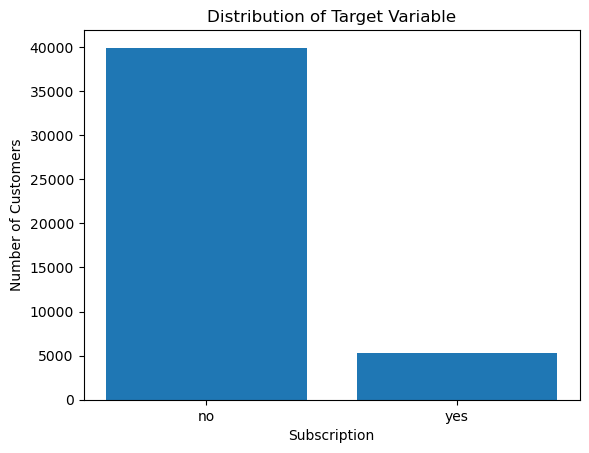

In [26]:
plt.bar(x=['no','yes'],height=df["y"].value_counts())
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.title('Distribution of Target Variable')
plt.show()

### 3.1.1 Interpretation

The target variable shows that 39,922 customers (88.30%) did not subscribe to a term deposit, while 5,289 customers (11.70%) subscribed.

The distribution indicates that the target variable is imbalanced, with the `no` class occurring much more frequently than the `yes` class. This class imbalance should be considered when building and evaluating the classification models.


### 3.2 Categorical Feature Analysis

The categorical features are analyzed to understand the distribution of customers across different categories. This helps identify the most common customer characteristics and campaign-related categories in the dataset.


In [27]:
df['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [28]:
df['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

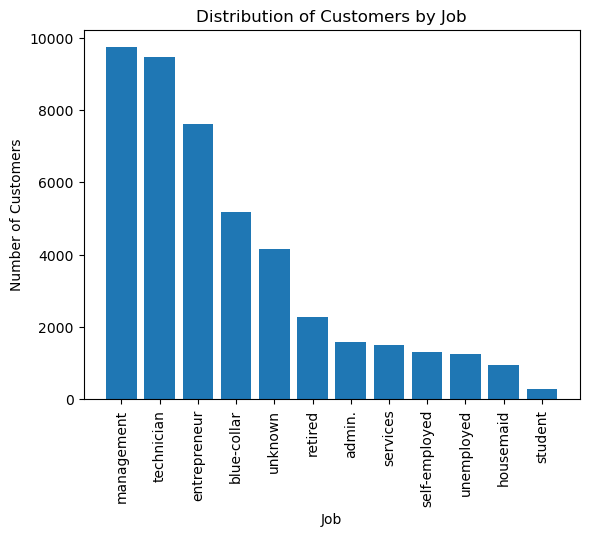

In [29]:
plt.bar(x=['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'],height=df['job'].value_counts())
plt.xticks(rotation=90)
plt.xlabel('Job')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Job')
plt.show()

In [30]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [31]:
df['marital'].unique()

array(['married', 'single', 'divorced'], dtype=object)

In [32]:
df['marital'].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

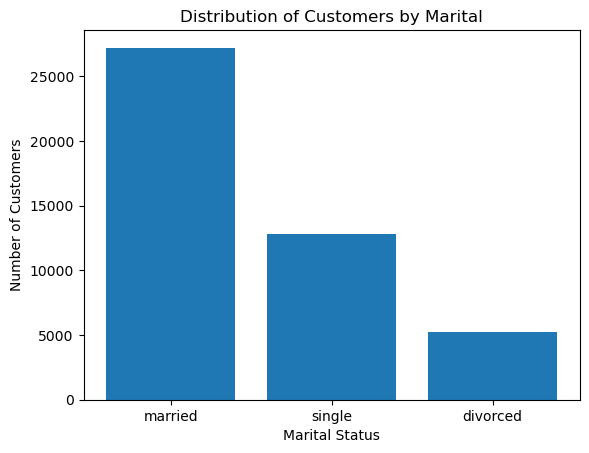

In [33]:
plt.bar(x=['married', 'single', 'divorced'],height=df['marital'].value_counts())

plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Marital')
plt.show()

In [34]:
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [35]:
df['education'].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

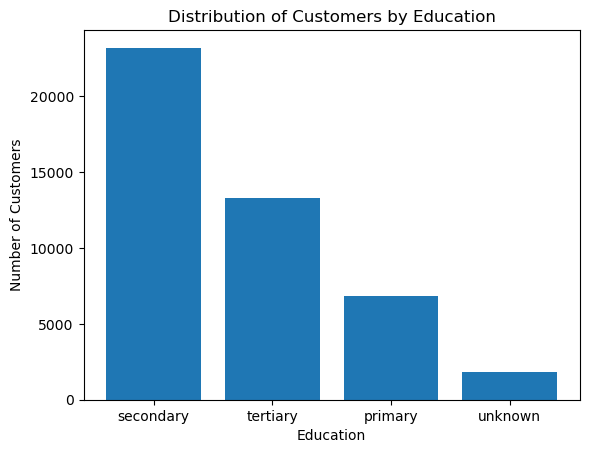

In [36]:
plt.bar(x=[ 'secondary', 'tertiary', 'primary','unknown'],height=df['education'].value_counts())
plt.xlabel('Education')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Education')
plt.show()

In [37]:
df['default'].value_counts()

default
no     44396
yes      815
Name: count, dtype: int64

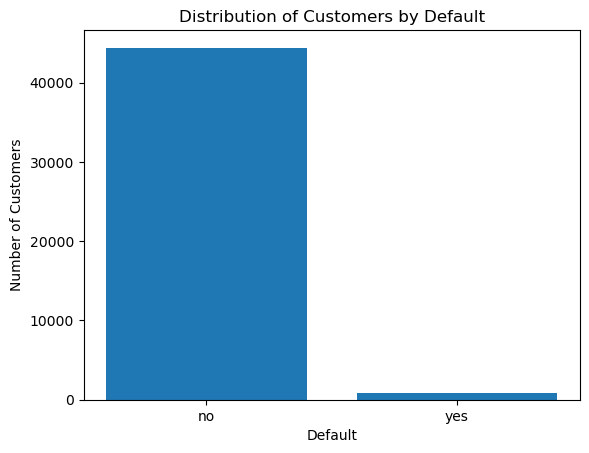

In [38]:
plt.bar(x=[ 'no','yes'],height=df['default'].value_counts())
plt.xlabel('Default')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Default')
plt.show()

In [39]:
df['housing'].value_counts()

housing
yes    25130
no     20081
Name: count, dtype: int64

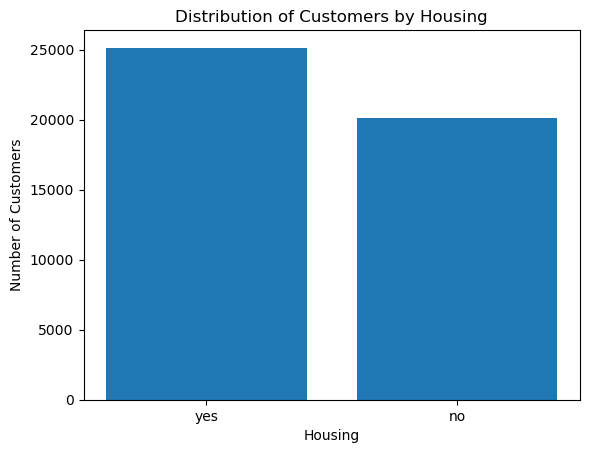

In [40]:
plt.bar(x=[ 'yes','no'],height=df['housing'].value_counts())
plt.xlabel('Housing')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Housing')
plt.show()

In [41]:
df['loan'].value_counts()

loan
no     37967
yes     7244
Name: count, dtype: int64

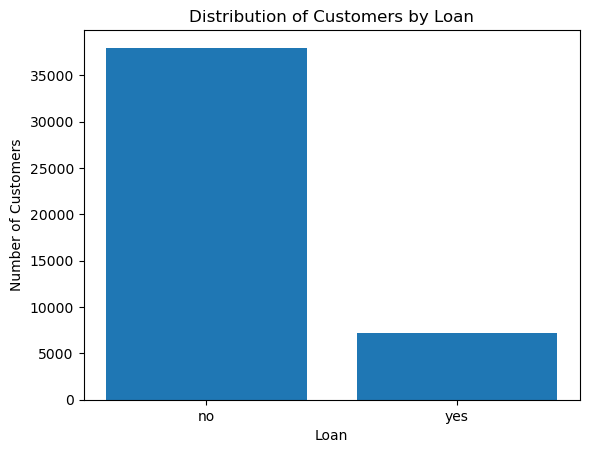

In [42]:
plt.bar(x=[ 'no','yes'],height=df['loan'].value_counts())
plt.xlabel('Loan')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Loan')
plt.show()

In [43]:
df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

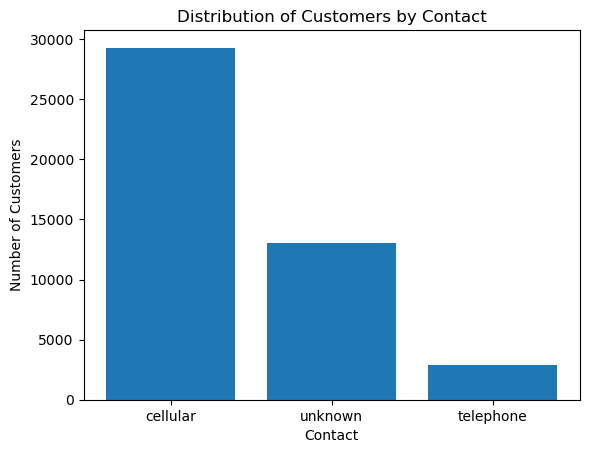

In [44]:
plt.bar(x=[ 'cellular','unknown','telephone'],height=df['contact'].value_counts())
plt.xlabel('Contact')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Contact')
plt.show()

In [45]:
df['month'].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

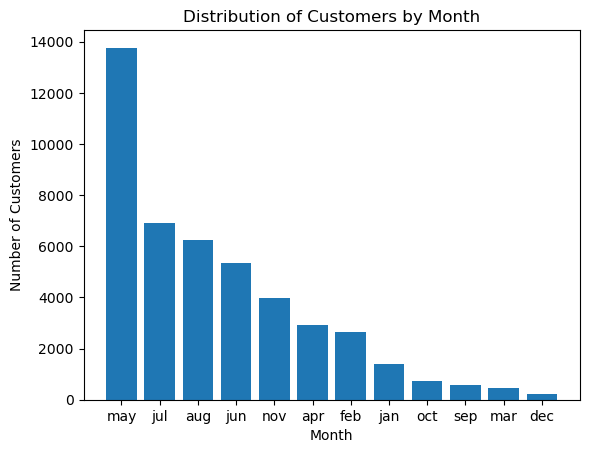

In [46]:
plt.bar(x=[ 'may','jul','aug','jun','nov','apr','feb','jan','oct','sep','mar','dec'],height=df['month'].value_counts())
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by Month')
plt.show()

In [47]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

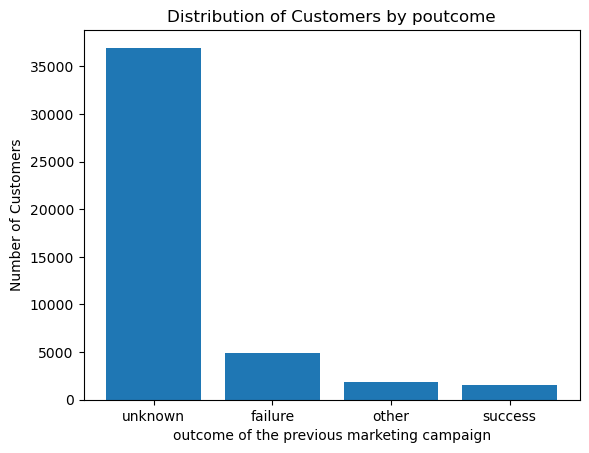

In [48]:
plt.bar(x=[ 'unknown','failure','other','success'],height=df['poutcome'].value_counts())
plt.xlabel('outcome of the previous marketing campaign')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customers by poutcome')
plt.show()

### 3.3 Numerical Feature Analysis

The numerical features are analyzed to understand their distributions, central tendencies, spread, and potential extreme values. Histograms, KDE plots, and boxplots will be used to visualize the numerical variables.


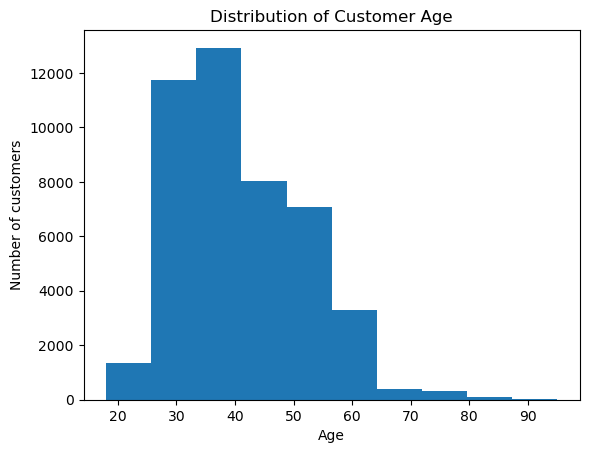

In [49]:
plt.hist(df['age'])
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.title('Distribution of Customer Age')
plt.show()

### 3.3.1 Age Distribution – Interpretation

The age distribution shows that most customers are concentrated approximately between 30 and 50 years of age. Customers below 30 years are comparatively fewer, while the number of customers gradually decreases for older age groups. Customers above 60 years are relatively fewer in the dataset.

Overall, the dataset contains a higher representation of middle-aged customers compared with very young and older customers.


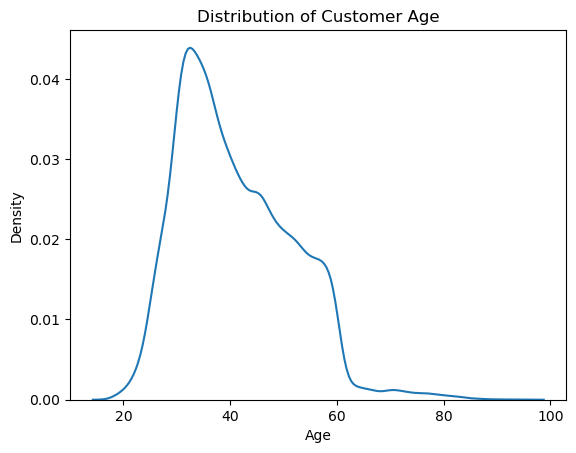

In [50]:
sns.kdeplot(df['age'])
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Distribution of Customer Age')
plt.show()

### 3.3.2 Age KDE Plot – Interpretation

The KDE plot shows that customer ages are mainly concentrated around 30–40 years. The distribution has a longer tail toward the older age groups, indicating that the age variable is right-skewed (positively skewed).

This suggests that most customers are relatively younger or middle-aged, while a smaller number of customers belong to older age groups.


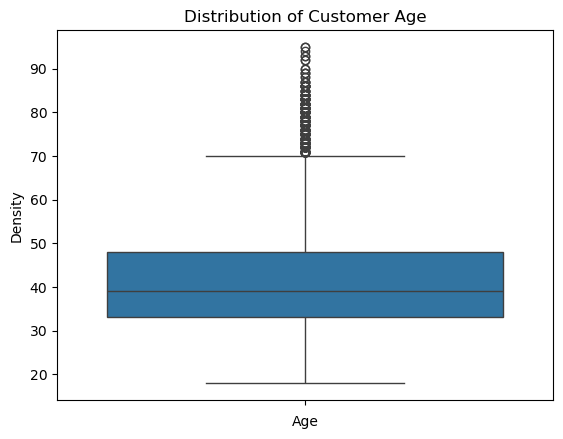

In [51]:
sns.boxplot(df['age'])
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Distribution of Customer Age')
plt.show()

### 3.3.3 Age Boxplot – Interpretation

The boxplot shows that the median customer age is approximately 39–40 years. The middle 50% of customer ages lies approximately between 33 and 48 years.

Several observations appear beyond the upper whisker and are identified as potential outliers. However, these observations may represent genuine older customers and are not considered data errors solely based on the boxplot.


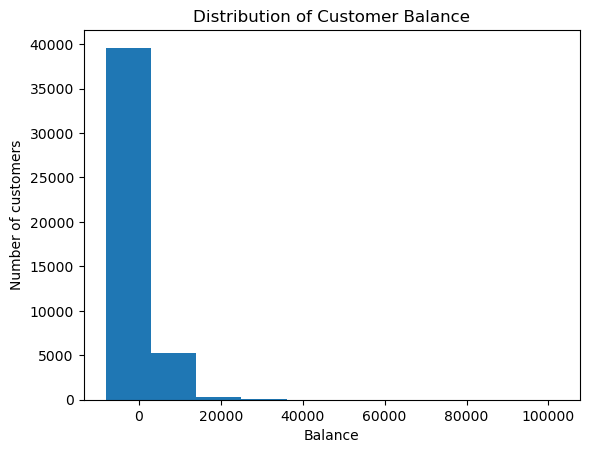

In [52]:
plt.hist(df['balance'])
plt.xlabel('Balance')
plt.ylabel('Number of customers')
plt.title('Distribution of Customer Balance')
plt.show()

### 3.3.4.1 Balance Histogram – Interpretation

The histogram shows that most customer balances are concentrated below 10,000. The distribution is strongly right-skewed, with a long tail extending toward higher balance values.

Several customers have very large positive balances, including values above 40,000, indicating the presence of extreme observations. These values should be investigated further rather than removed automatically.


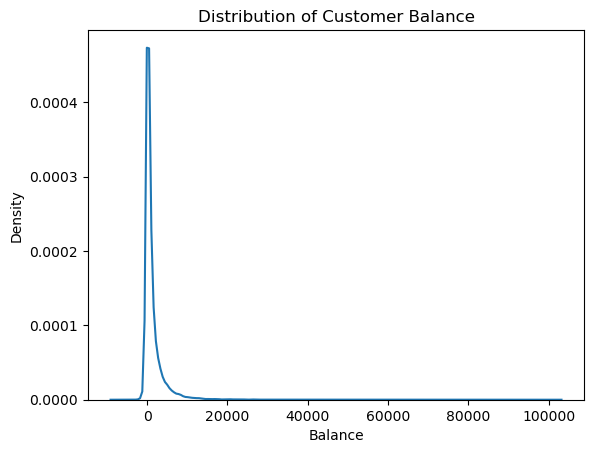

In [53]:
sns.kdeplot(df['balance'])
plt.xlabel('Balance')
plt.ylabel('Density')
plt.title('Distribution of Customer Balance')
plt.show()

### 3.3.5 Balance KDE Plot – Interpretation

The KDE plot shows that customer balances are mainly concentrated around relatively low balance values, close to zero. The distribution has a long tail toward higher positive balances, indicating a strong right-skewed (positively skewed) distribution.

This suggests that while most customers have relatively low balances, a smaller number of customers have substantially higher balances.


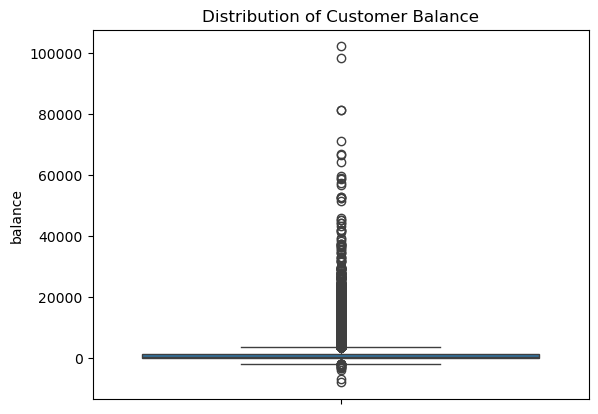

In [54]:
sns.boxplot(df['balance'])
plt.title('Distribution of Customer Balance')
plt.show()

### 3.3.6 Balance Boxplot – Interpretation

The boxplot shows that the median customer balance is around 448. The middle 50% of observations are concentrated within a relatively small range compared with the overall range of the feature.

A large number of observations appear beyond the upper whisker, indicating potential outliers on the higher-balance side. This supports the right-skewed distribution observed in the histogram and KDE plot.

These extreme balance values may represent genuine customer financial characteristics and should not be removed automatically.


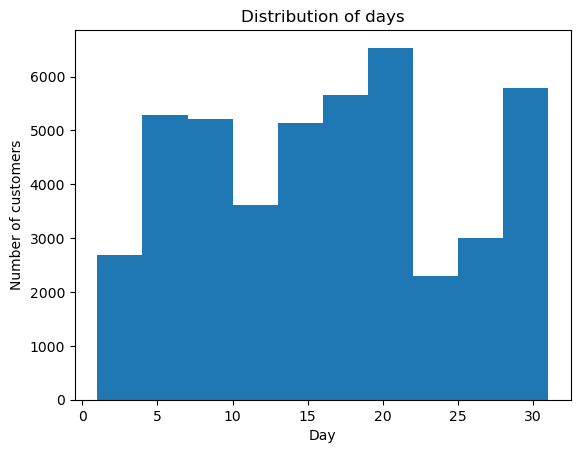

In [55]:
plt.hist(df['day'])
plt.xlabel('Day')
plt.ylabel('Number of customers')
plt.title('Distribution of days')
plt.show()

### 3.3.7 Day Histogram – Interpretation

The histogram shows that customers are relatively distributed across the different days of the month. Some variation in frequency can be observed, with comparatively higher frequencies around days 18–20 and lower frequencies in some parts of the 20–25 range.

Overall, the distribution does not show a strong skewed pattern and appears approximately balanced across the days of the month.


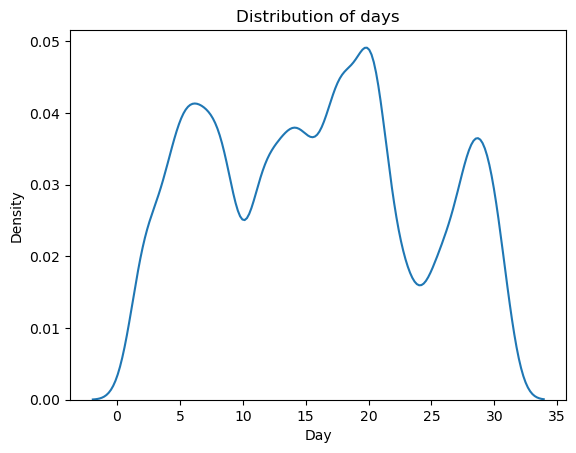

In [56]:
sns.kdeplot(df['day'])
plt.xlabel('Day')
plt.ylabel('Density')
plt.title('Distribution of days')
plt.show()

### 3.3.8 Day KDE Plot – Interpretation

The KDE plot shows that the density of customer contacts is relatively higher around days 15–20. The distribution appears approximately balanced, with no strong skewness toward either side.

Overall, the `day` feature does not show a pronounced skewed distribution.


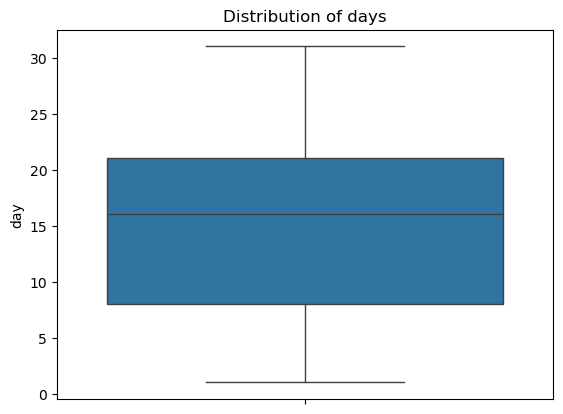

In [57]:
sns.boxplot(df['day'])
plt.title('Distribution of days')
plt.show()

### 3.3.9 Day Boxplot – Interpretation

The boxplot shows that the median day of customer contact is approximately 16. The middle 50% of observations lies between approximately day 8 and day 21.

No potential outliers are observed in the `day` feature. Overall, the feature has a relatively balanced distribution without extreme observations.


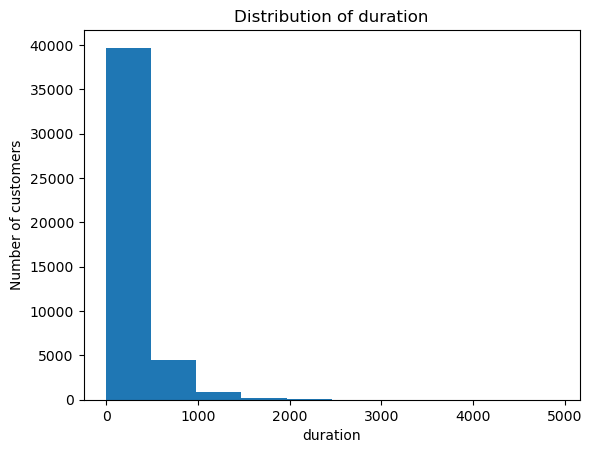

In [58]:
plt.hist(df['duration'])
plt.xlabel('duration')
plt.ylabel('Number of customers')
plt.title('Distribution of duration')
plt.show()

### 3.3.10 Duration Histogram – Interpretation

The histogram shows that most customer calls are concentrated within the lower duration range, approximately 0–500 seconds. The distribution has a long tail extending toward higher durations, indicating a right-skewed (positively skewed) distribution.

Only a relatively small number of calls have very long durations compared with the majority of observations.


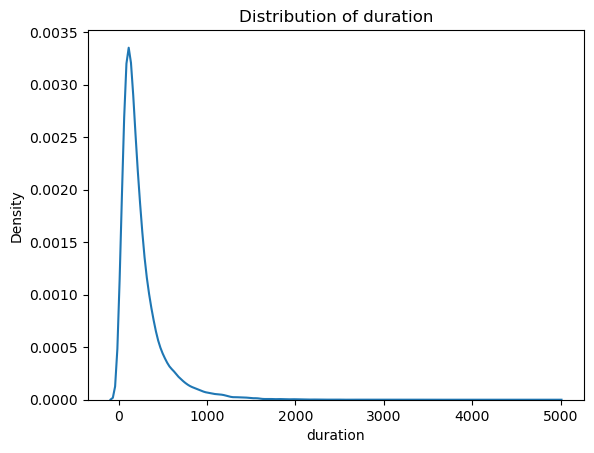

In [59]:
sns.kdeplot(df['duration'])
plt.xlabel('duration')
plt.ylabel('Density')
plt.title('Distribution of duration')
plt.show()

### 3.3.11 Duration KDE Plot – Interpretation

The KDE plot shows that the highest density of customer call durations is concentrated approximately between 0 and 200 seconds. The distribution has a long tail toward higher durations, indicating that the `duration` feature is strongly right-skewed.

The long right tail indicates that relatively few customers had very long calls compared with the majority of observations.


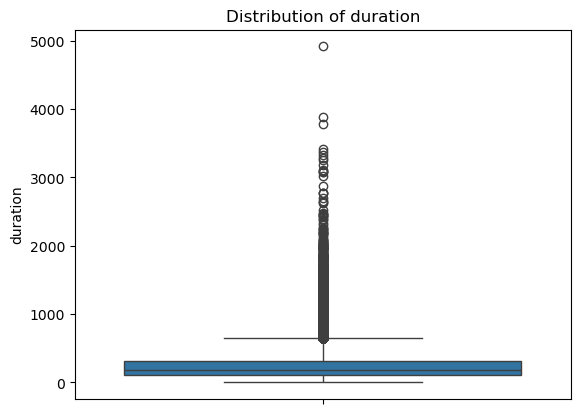

In [60]:
sns.boxplot(df['duration'])
plt.title('Distribution of duration')
plt.show()

### 3.3.12 Duration Boxplot – Interpretation

The boxplot shows that the median call duration is approximately 180 seconds. The middle 50% of call durations lies approximately between 100 and 320 seconds.

A large number of observations appear beyond the upper whisker, indicating potential outliers on the higher-duration side. These observations may represent genuine long customer calls and should not be removed automatically.

Overall, the boxplot supports the right-skewed distribution observed in the histogram and KDE plot.


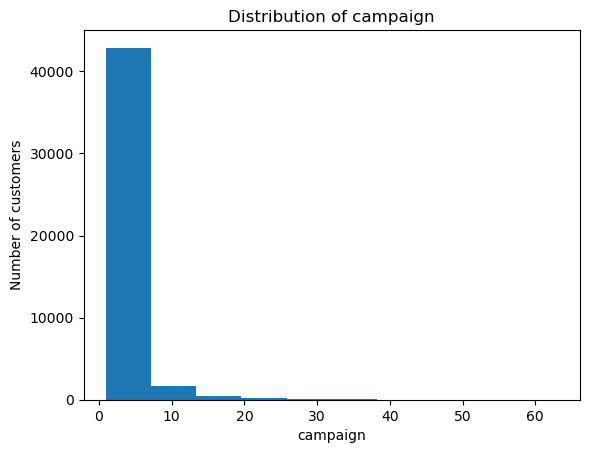

In [61]:
plt.hist(df['campaign'])
plt.xlabel('campaign')
plt.ylabel('Number of customers')
plt.title('Distribution of campaign')
plt.show()

### 3.3.13 Campaign Histogram – Interpretation

The histogram shows that most customers were contacted approximately between 1 and 5 campaigns. The frequency decreases as the number of contacts increases.

The distribution has a long tail toward higher campaign values, indicating that the `campaign` feature is right-skewed (positively skewed).

A relatively small number of customers have been contacted many times, resulting in high campaign values.


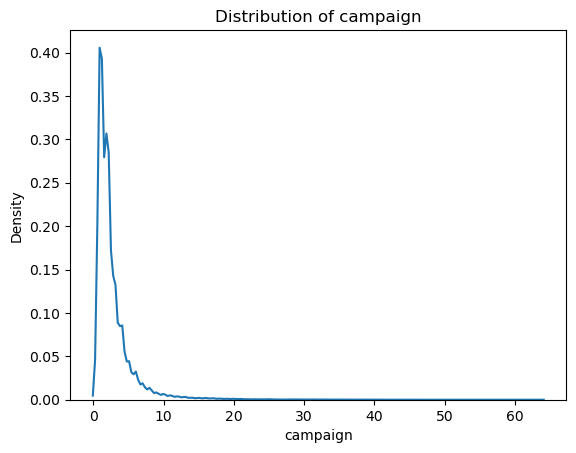

In [62]:
sns.kdeplot(df['campaign'])
plt.xlabel('campaign')
plt.ylabel('Density')
plt.title('Distribution of campaign')
plt.show()

### 3.3.14 Campaign KDE Plot – Interpretation

The KDE plot shows that the highest density of customers is concentrated approximately between 1 and 5 campaign contacts.

The distribution has a long tail toward higher campaign values, indicating that the `campaign` feature is right-skewed (positively skewed).

This shows that most customers were contacted only a few times, while a smaller number of customers were contacted many times.


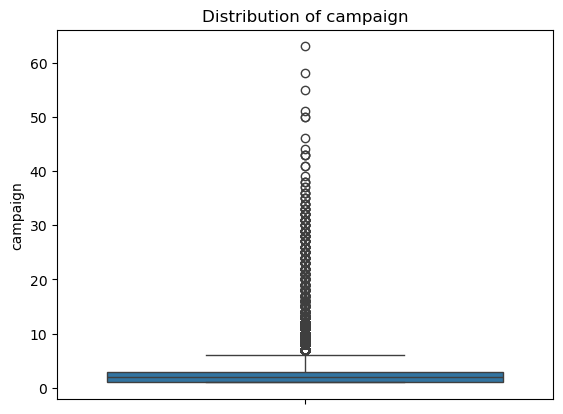

In [63]:
sns.boxplot(df['campaign'])
plt.title('Distribution of campaign')
plt.show()

### 3.3.15 Campaign Boxplot – Interpretation

The boxplot shows that the median number of campaign contacts is approximately 2. The middle 50% of observations lies approximately between 1 and 3 contacts.

Several observations appear beyond the upper whisker, indicating potential outliers with a high number of campaign contacts.

These high values may represent genuine repeated contacts with customers and should not be removed automatically. The boxplot also supports the right-skewed distribution observed in the histogram and KDE plot.


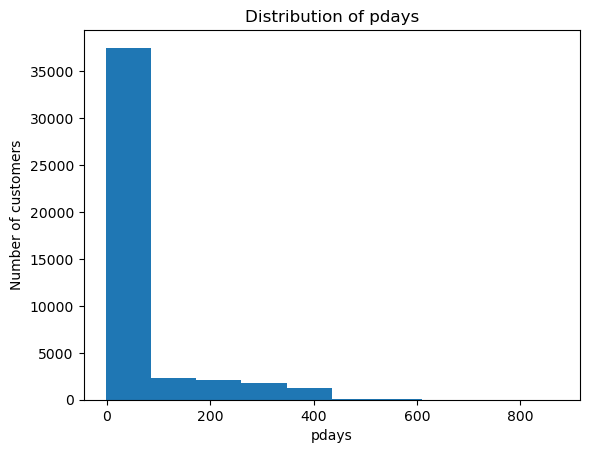

In [64]:
plt.hist(df['pdays'])
plt.xlabel('pdays')
plt.ylabel('Number of customers')
plt.title('Distribution of pdays')
plt.show()

### 3.3.16 Pdays Histogram – Interpretation

The histogram shows that many observations are concentrated at lower `pdays` values, particularly within approximately 0–100 days. The feature also contains a large number of `-1` values, which indicates that the customer was not previously contacted.

Among the positive `pdays` values, the distribution has a long tail toward higher values, indicating a right-skewed distribution.

The higher `pdays` values represent customers who were contacted after longer intervals and should not automatically be treated as errors.


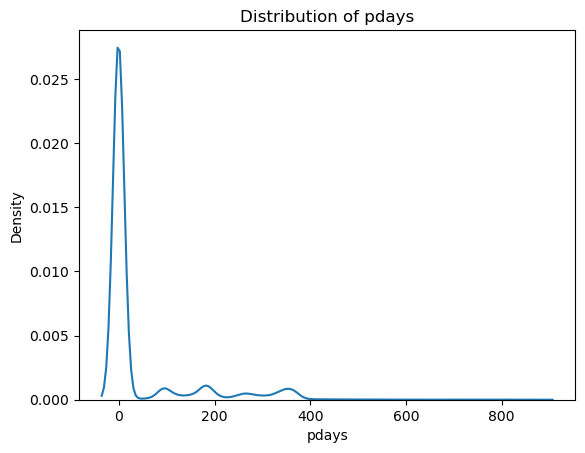

In [65]:
sns.kdeplot(df['pdays'])
plt.xlabel('pdays')
plt.ylabel('Density')
plt.title('Distribution of pdays')
plt.show()

### 3.3.17 Pdays KDE Plot – Interpretation

The KDE plot shows that the highest density of observations is concentrated approximately between -1 and 50 days.

The distribution has a long tail toward higher `pdays` values, indicating that the feature is right-skewed (positively skewed).

The high density around -1 is important because `-1` represents customers who were not previously contacted. Therefore, this value should be treated as a meaningful category or indicator rather than as an ordinary numerical outlier.


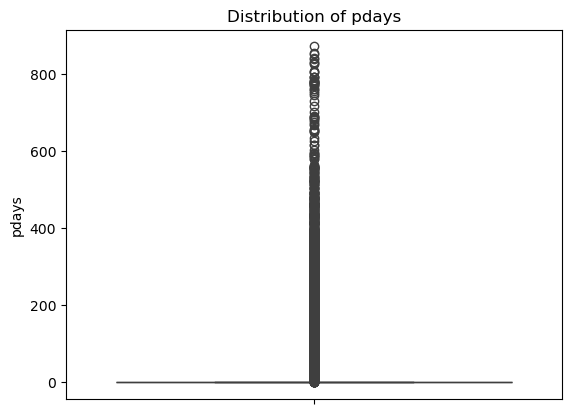

In [66]:
sns.boxplot(df['pdays'])
plt.title('Distribution of pdays')
plt.show()

### 3.3.18 Pdays Boxplot – Interpretation

The boxplot shows that the median value of `pdays` is approximately -1. The interquartile range is 0 because a large proportion of observations have the value -1.

Many observations appear beyond the upper whisker and are identified as potential outliers by the IQR method. However, these values are not necessarily errors. Positive `pdays` values represent the number of days since a customer was previously contacted.

Therefore, the potential outliers should not be removed automatically. The special meaning of `-1` should also be considered during feature engineering and model preparation.


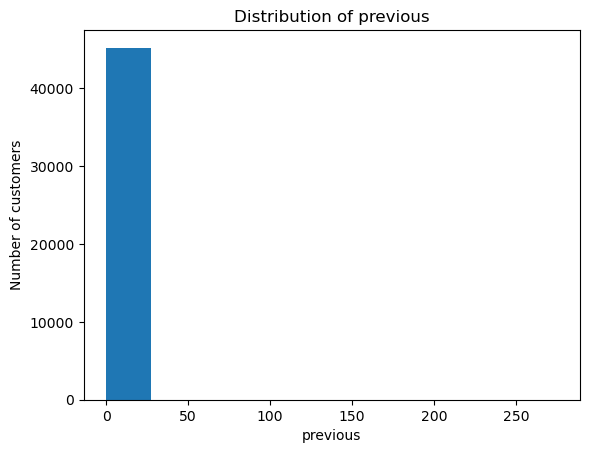

In [67]:
plt.hist(df['previous'])
plt.xlabel('previous')
plt.ylabel('Number of customers')
plt.title('Distribution of previous')
plt.show()

### 3.3.19 Previous Histogram – Interpretation

The histogram shows that most customers have a `previous` value close to 0, with relatively fewer customers having a larger number of previous contacts.

The distribution is concentrated at the lower values and has a long tail toward higher values, indicating that the `previous` feature is right-skewed (positively skewed).

A small number of customers have been contacted many times in previous campaigns.


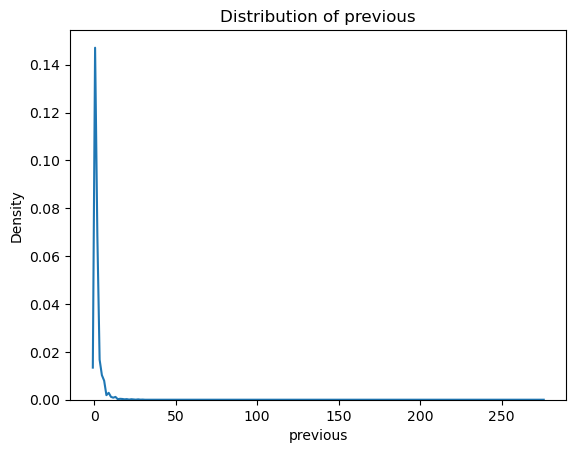

In [68]:
sns.kdeplot(df['previous'])
plt.xlabel('previous')
plt.ylabel('Density')
plt.title('Distribution of previous')
plt.show()

### 3.3.20 Previous KDE Plot – Interpretation

The KDE plot shows that the highest density of observations is concentrated around 0 previous contacts.

The distribution has a long tail toward higher values, indicating that the `previous` feature is right-skewed (positively skewed).

This indicates that most customers had no previous contacts before the current campaign, while a smaller number of customers had been contacted several times previously.


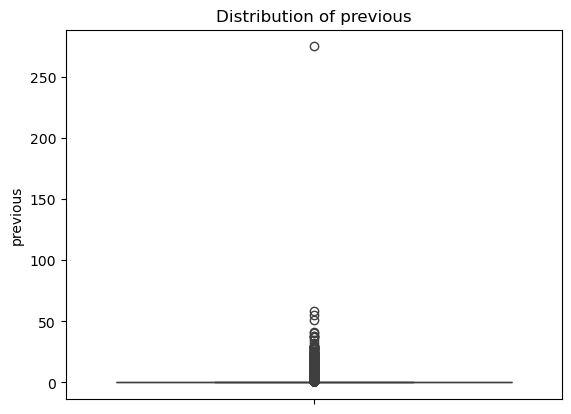

In [69]:
sns.boxplot(df['previous'])
plt.title('Distribution of previous')
plt.show()

### 3.3.21 Previous Boxplot – Interpretation

The boxplot shows that the median value of `previous` is 0. The interquartile range is 0 because a large proportion of customers have no previous contacts.

Several observations appear beyond the upper whisker and are identified as potential outliers. These observations may represent customers who had been contacted multiple times in previous campaigns and should not be removed automatically.

The boxplot supports the right-skewed distribution observed in the histogram and KDE plot.


### 3.4 Numerical Features vs Target

The numerical features are further analyzed in relation to the target variable `y` to understand whether their distributions differ between customers who subscribed to a term deposit and those who did not.

Boxplots will be used to compare the numerical features across the two target classes, `yes` and `no`. This analysis helps identify differences, patterns, and potential relationships between the numerical features and customer subscription outcomes.


<Axes: xlabel='age', ylabel='y'>

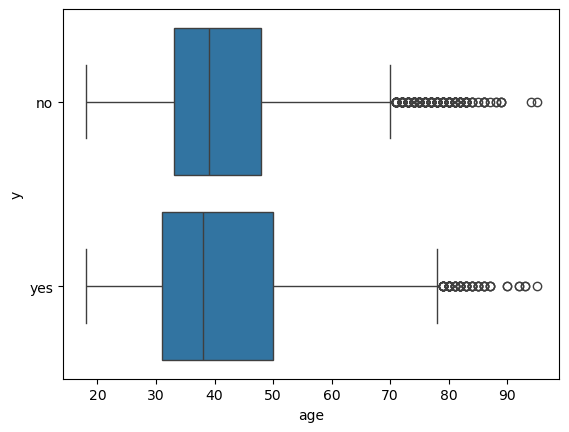

In [70]:
sns.boxplot(x=df['age'],y=df['y'])

### 3.4.1 Age vs Target – Interpretation

The boxplot shows that the median age of customers who did not subscribe is approximately 37–38 years, while the median age of customers who subscribed is approximately 39 years.

The `yes` group therefore has a slightly higher median age than the `no` group. However, there is considerable overlap between the two distributions, indicating that age alone does not clearly distinguish customers based on their subscription outcome.

Several potential outliers are also observed, mainly among the higher age values.


<Axes: xlabel='balance', ylabel='y'>

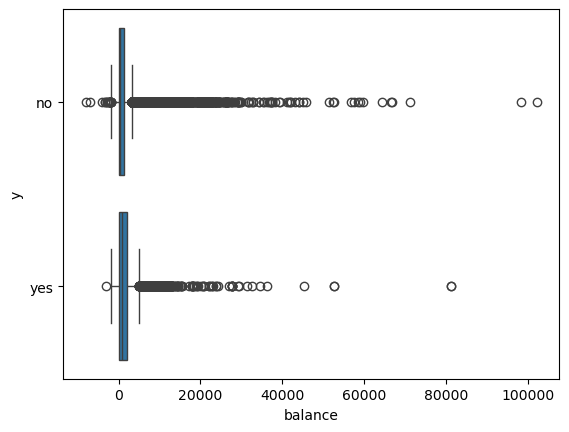

In [71]:
sns.boxplot(x=df['balance'],y=df['y'])

### 3.4.2 Balance vs Target – Interpretation

The boxplot shows that the median balance is relatively low for both target groups. The median balance of customers who subscribed is somewhat higher than that of customers who did not subscribe.

A large number of potential outliers are observed on the higher-balance side, which is consistent with the strong right-skewed distribution of the `balance` feature.

Although the subscribed group shows a higher median balance, there is considerable overlap between the two groups, so balance alone does not clearly distinguish the subscription outcome.


<Axes: xlabel='day', ylabel='y'>

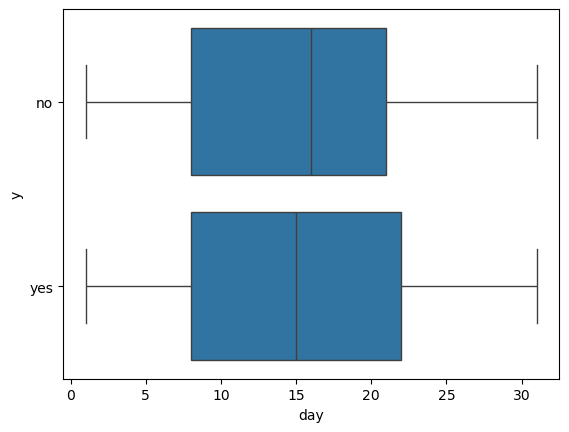

In [72]:
sns.boxplot(data=df,x='day',y='y')

### 3.4.3 Day vs Target – Interpretation

The boxplot shows that the median day of contact is approximately 16–17 for customers who did not subscribe, while the median for customers who subscribed is approximately 15.

The `no` group therefore has a slightly higher median day than the `yes` group. However, the difference between the two groups is small, and their distributions show considerable overlap.

No significant potential outliers are observed in either target group. Overall, the `day` feature does not show a strong difference between the two subscription outcomes.


<Axes: xlabel='duration', ylabel='y'>

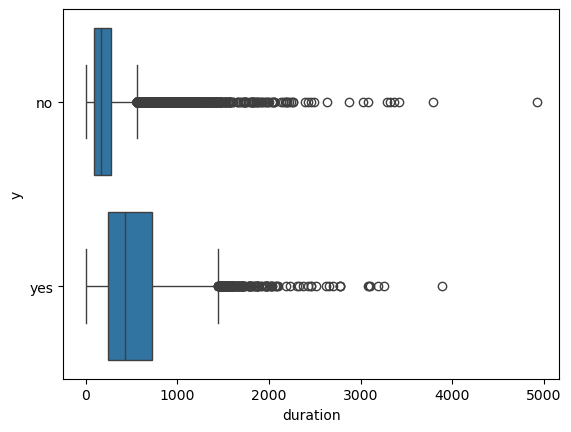

In [73]:
sns.boxplot(data=df,x='duration',y='y')

### 3.4.4 Duration vs Target – Interpretation

The boxplot shows that the median call duration for customers who did not subscribe is approximately 100 seconds, while the median duration for customers who subscribed is approximately 200–300 seconds.

The `yes` group therefore has a considerably higher median call duration than the `no` group. This suggests that customers who subscribed generally had longer conversations during the campaign.

Several potential outliers are observed, particularly at higher call durations. These values may represent genuine long customer calls and should not be removed automatically.

Overall, `duration` shows a noticeable difference between the two target groups and may be an important feature for predicting the subscription outcome.


<Axes: xlabel='campaign', ylabel='y'>

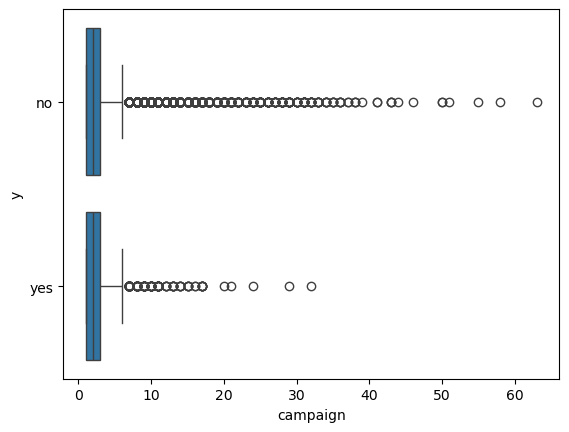

In [74]:
sns.boxplot(data=df,x='campaign',y='y')

### 3.4.5 Campaign vs Target – Interpretation

The boxplot shows that the median number of campaign contacts is approximately 1–2 for customers who did not subscribe, while the median for customers who subscribed is approximately 1–3 contacts.

The `yes` group therefore has a slightly higher median number of campaign contacts than the `no` group. However, there is considerable overlap between the two groups.

Several potential outliers are observed at higher campaign values. These values may represent customers who were contacted multiple times and should not be removed automatically.

Overall, `campaign` shows some difference between the two target groups, but the overlap suggests that this feature alone may not clearly distinguish the subscription outcome.


<Axes: xlabel='pdays', ylabel='y'>

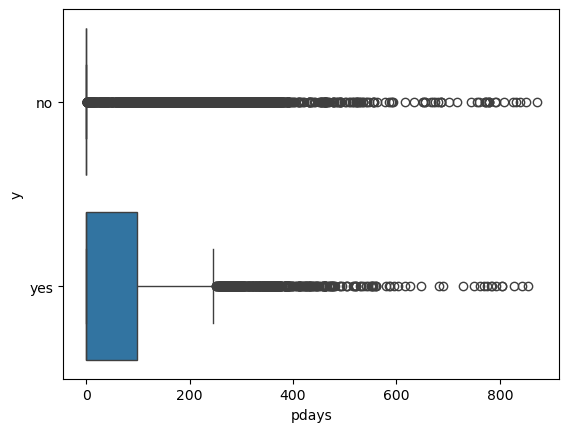

In [75]:
sns.boxplot(data=df,x='pdays',y='y')

### 3.4.6 Pdays vs Target – Interpretation

The boxplot shows that the median `pdays` value is approximately 0 for customers who did not subscribe, while the median for customers who subscribed is approximately -1.

The `no` group therefore has a slightly higher median `pdays` value than the `yes` group.

Several observations appear beyond the upper whisker and are identified as potential outliers. However, these values may represent valid numbers of days since a customer was previously contacted and should not be removed automatically.

The value `-1` is also meaningful because it indicates that the customer was not previously contacted. Therefore, it should not be treated as an ordinary numerical outlier during preprocessing.


<Axes: xlabel='previous', ylabel='y'>

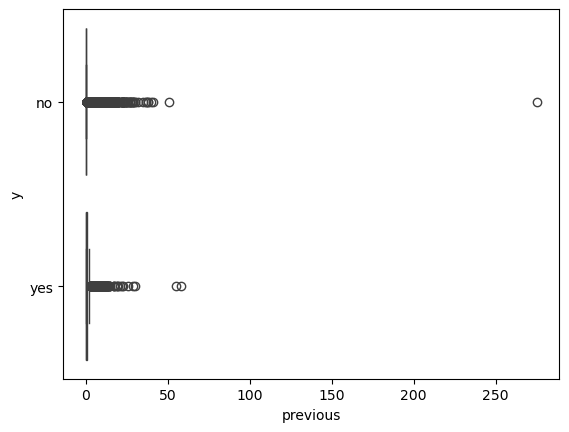

In [76]:
sns.boxplot(data=df,x='previous',y='y')

### 3.4.7 Previous vs Target – Interpretation

The boxplot shows that the median value of `previous` is 0 for both customers who did not subscribe and customers who subscribed.

This indicates that the typical customer in both target groups had no previous contacts before the current campaign.

Several observations appear beyond the upper whisker and are identified as potential outliers. However, these values may represent customers who were contacted multiple times in previous campaigns and should not be removed automatically.

Overall, `previous` does not show a noticeable difference in median values between the two target groups, although the feature may still provide useful information when combined with other features.


### 3.5 Categorical Features vs Target

The categorical features are further analyzed in relation to the target variable `y` to understand whether customer characteristics and campaign-related categories are associated with subscription outcomes.

Count plots will be used to compare the distribution of the `yes` and `no` target classes across different categorical features. This analysis helps identify patterns and differences in subscription outcomes among different customer groups.


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'management'),
  Text(1, 0, 'technician'),
  Text(2, 0, 'entrepreneur'),
  Text(3, 0, 'blue-collar'),
  Text(4, 0, 'unknown'),
  Text(5, 0, 'retired'),
  Text(6, 0, 'admin.'),
  Text(7, 0, 'services'),
  Text(8, 0, 'self-employed'),
  Text(9, 0, 'unemployed'),
  Text(10, 0, 'housemaid'),
  Text(11, 0, 'student')])

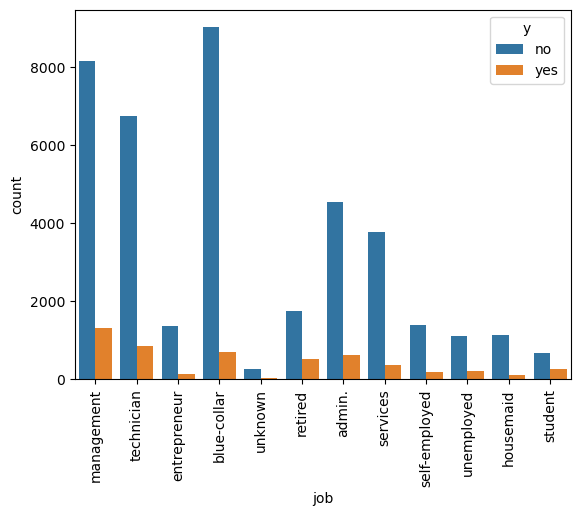

In [77]:
sns.countplot(data=df,x='job',hue='y')
plt.xticks(rotation=90)

### 3.5.1 Job vs Target – Interpretation

The count plot shows the distribution of subscription outcomes across different job categories.

The management category has the highest number of customers who subscribed to a term deposit (`yes`). The `unknown` job category has the lowest number of `yes` subscriptions.

The `no` class is substantially higher than the `yes` class across most job categories, which is consistent with the overall class imbalance in the target variable.

The number of subscriptions should be interpreted together with the total number of customers in each job category, since a higher count of `yes` does not necessarily indicate a higher subscription rate.


<Axes: xlabel='marital', ylabel='count'>

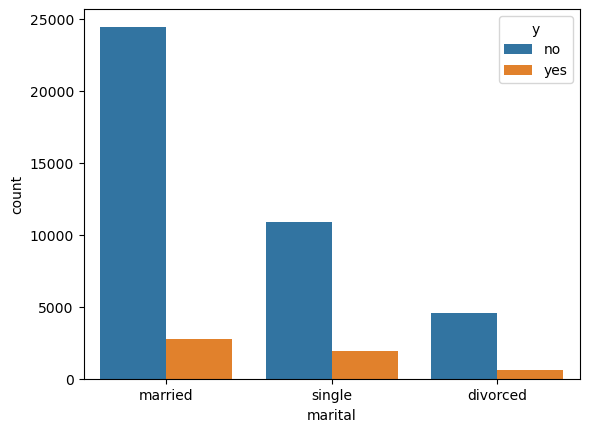

In [78]:
sns.countplot(data=df,x='marital',hue='y')

### 3.5.2 Marital Status vs Target – Interpretation

The count plot shows the distribution of subscription outcomes across different marital-status categories.

The married category has the highest number of customers who subscribed to a term deposit (`yes`), while the divorced category has the lowest number of `yes` subscriptions.

The `no` class is substantially higher than the `yes` class across all marital-status categories, which is consistent with the overall class imbalance in the dataset.

The observed counts should be interpreted together with the total number of customers in each category, since a higher number of `yes` subscriptions does not necessarily indicate a higher subscription rate.


<Axes: xlabel='education', ylabel='count'>

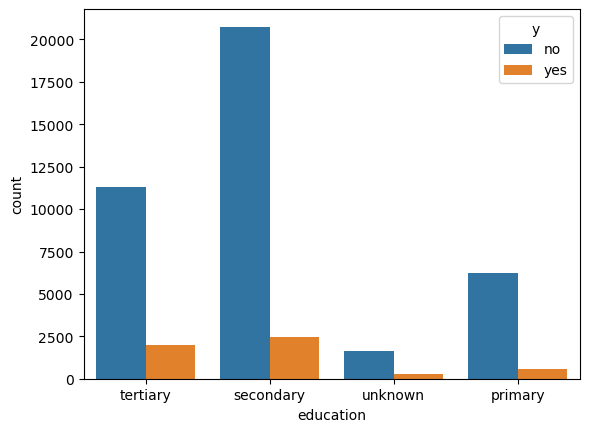

In [79]:
sns.countplot(data=df,x='education',hue='y')

### 3.5.3 Education vs Target – Interpretation

The count plot shows the distribution of subscription outcomes across different education categories.

The secondary education category has the highest number of customers who subscribed to a term deposit (`yes`), while the unknown education category has the lowest number of `yes` subscriptions.

The `no` class is substantially higher than the `yes` class across all education categories, which is consistent with the overall class imbalance in the dataset.

The counts should be interpreted together with the total number of customers in each education category, since a higher number of `yes` subscriptions does not necessarily indicate a higher subscription rate.


<Axes: xlabel='default', ylabel='count'>

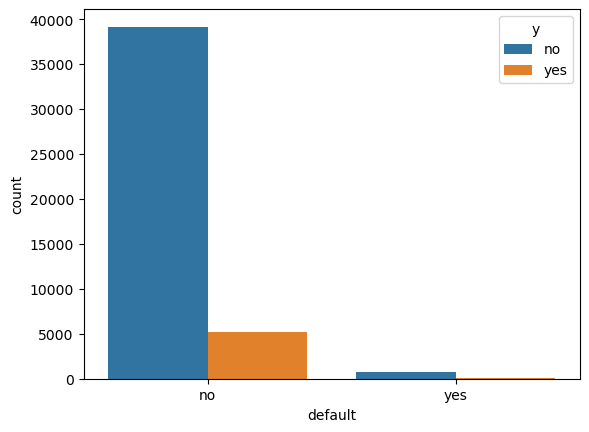

In [80]:
sns.countplot(data=df,x='default',hue='y')

### 3.5.4 Default vs Target – Interpretation

The count plot shows the distribution of subscription outcomes across customers with different default statuses.

Customers with `default = no` have a much higher number of `yes` subscriptions compared with customers with `default = yes`. The `default = yes` category contains relatively few customers and therefore has a much smaller number of `yes` subscriptions.

Overall, the `no` target class is substantially higher than the `yes` class in both default categories, which is consistent with the overall class imbalance.

Since the `default` feature is itself highly imbalanced, the subscription counts should be interpreted together with the number of customers in each default category.


<Axes: xlabel='housing', ylabel='count'>

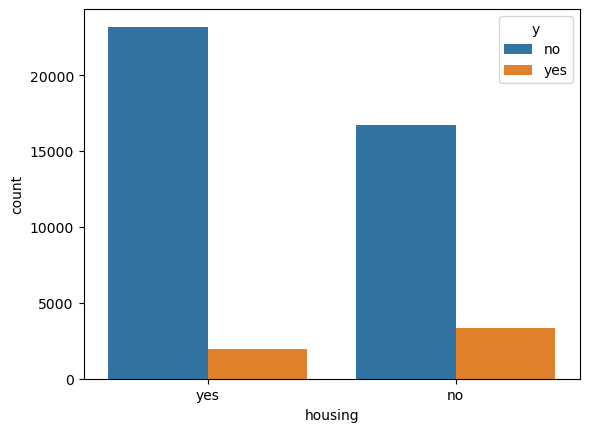

In [81]:
sns.countplot(data=df,x='housing',hue='y')

### 3.5.5 Housing vs Target – Interpretation

The count plot shows the distribution of subscription outcomes across customers based on their housing-loan status.

Customers with `housing = no` have a higher number of `yes` subscriptions compared with customers with `housing = yes`.

The `no` target class is substantially higher than the `yes` class in both housing categories, which is consistent with the overall class imbalance in the dataset.

The observed values represent subscription counts rather than subscription rates. Therefore, the results should be interpreted together with the total number of customers in each housing category.


<Axes: xlabel='loan', ylabel='count'>

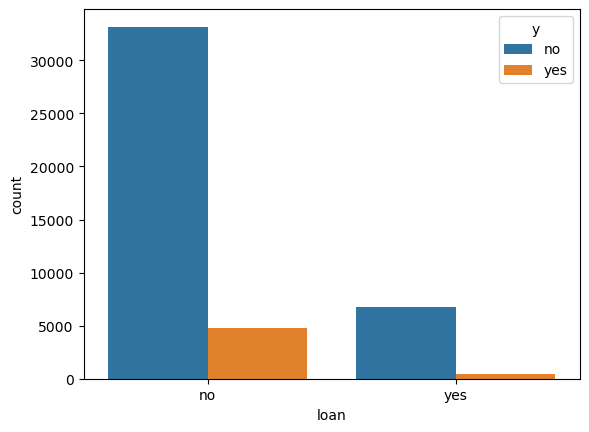

In [82]:
sns.countplot(data=df,x='loan',hue='y')

### 3.5.6 Loan vs Target – Interpretation

The count plot shows the distribution of subscription outcomes based on whether customers have a personal loan.

Customers with `loan = no` have a higher number of `yes` subscriptions compared with customers with `loan = yes`.

The `no` target class is substantially higher than the `yes` class in both loan categories, which is consistent with the overall class imbalance in the dataset.

The plot shows subscription counts rather than subscription rates, so the differences should be interpreted together with the total number of customers in each loan category.


<Axes: xlabel='contact', ylabel='count'>

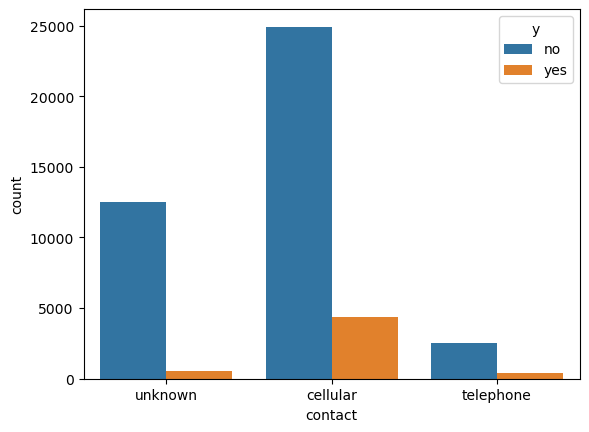

In [83]:
sns.countplot(data=df,x='contact',hue='y')

### 3.5.7 Contact vs Target – Interpretation

The count plot shows the distribution of subscription outcomes across different contact communication methods.

The cellular contact category has the highest number of customers who subscribed to a term deposit (`yes`), while the unknown contact category has the lowest number of `yes` subscriptions.

The `no` target class is substantially higher than the `yes` class across the contact categories, which is consistent with the overall class imbalance in the dataset.

The results represent subscription counts rather than subscription rates. Therefore, the number of customers in each contact category should also be considered when interpreting the differences.


<Axes: xlabel='month', ylabel='count'>

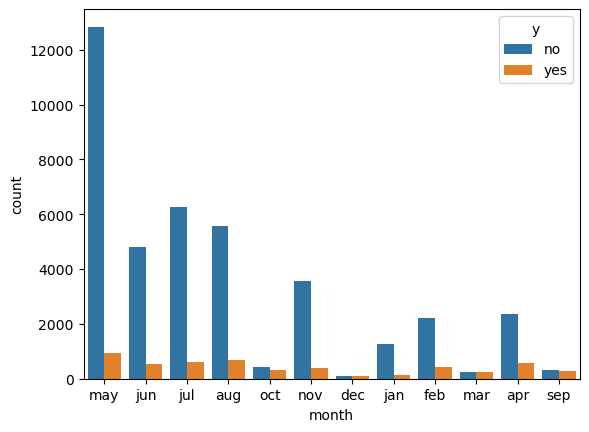

In [84]:
sns.countplot(data=df,x='month',hue='y')

### 3.5.8 Month vs Target – Interpretation

The count plot shows the distribution of subscription outcomes across the different months of the marketing campaign.

May has the highest number of customers who subscribed to a term deposit (`yes`), while December has the lowest number of `yes` subscriptions.

The `no` target class is substantially higher than the `yes` class across most months, which is consistent with the overall class imbalance in the dataset.

The differences should be interpreted together with the total number of customers contacted in each month, since the plot represents subscription counts rather than subscription rates.


<Axes: xlabel='poutcome', ylabel='count'>

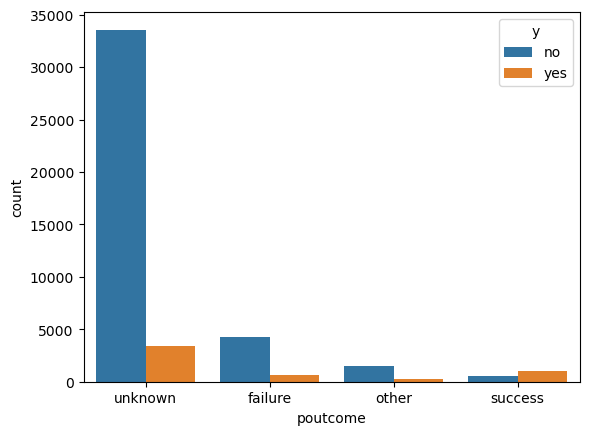

In [85]:
sns.countplot(data=df,x='poutcome',hue='y')

### 3.5.9 Poutcome vs Target – Interpretation

The count plot shows the distribution of subscription outcomes based on the outcome of the previous marketing campaign.

The `unknown` category has the highest number of customers who subscribed to a term deposit (`yes`), while the `other` category has the lowest number of `yes` subscriptions.

The `no` target class is substantially higher than the `yes` class across the categories, which is consistent with the overall class imbalance in the dataset.

The `unknown` category represents customers for whom the previous campaign outcome was not recorded. Therefore, the observed counts should be interpreted together with the size of each category rather than comparing the raw subscription counts alone.


### 3.6 Correlation Analysis

Correlation analysis is performed to understand the relationships between the numerical features in the dataset.

A correlation heatmap is used to visualize the strength and direction of relationships between numerical variables. This helps identify features that may have positive, negative, or weak relationships with each other.


In [86]:
df.select_dtypes(include='int')

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0
...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0
45207,71,1729,17,456,2,-1,0
45208,72,5715,17,1127,5,184,3
45209,57,668,17,508,4,-1,0


In [87]:
correlation_matrix= df.select_dtypes(include='int').corr()
print(correlation_matrix)

               age   balance       day  duration  campaign     pdays  previous
age       1.000000  0.097783 -0.009120 -0.004648  0.004760 -0.023758  0.001288
balance   0.097783  1.000000  0.004503  0.021560 -0.014578  0.003435  0.016674
day      -0.009120  0.004503  1.000000 -0.030206  0.162490 -0.093044 -0.051710
duration -0.004648  0.021560 -0.030206  1.000000 -0.084570 -0.001565  0.001203
campaign  0.004760 -0.014578  0.162490 -0.084570  1.000000 -0.088628 -0.032855
pdays    -0.023758  0.003435 -0.093044 -0.001565 -0.088628  1.000000  0.454820
previous  0.001288  0.016674 -0.051710  0.001203 -0.032855  0.454820  1.000000


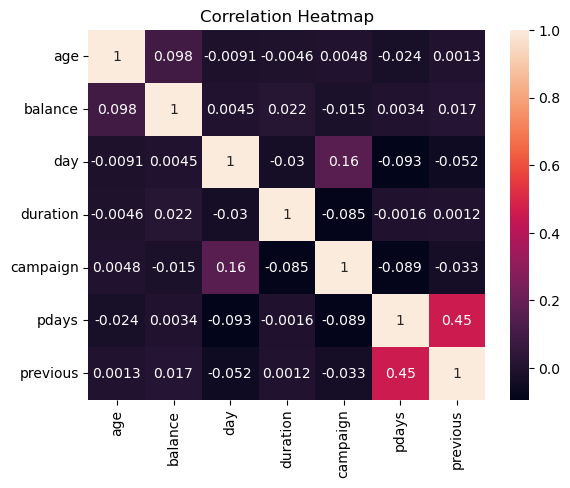

In [88]:
sns.heatmap(correlation_matrix,annot=True)
plt.title('Correlation Heatmap')
plt.show()

### 3.6.1 Correlation Heatmap – Interpretation

The correlation heatmap shows the relationships between the numerical features of the dataset.

Most of the numerical features have weak correlations with each other, as their correlation values are close to zero.

The strongest relationship is observed between `pdays` and `previous`, with a correlation of approximately 0.45, indicating a moderate positive linear relationship.

A weak positive correlation is observed between `day` and `campaign`, with a correlation of approximately 0.16. The remaining feature pairs show very weak positive or negative correlations.

Overall, there are no extremely strong correlations among the numerical features. This suggests that severe multicollinearity is not apparent among the numerical variables based on the correlation matrix.


### 3.7 Exploratory Data Analysis – Summary

The exploratory data analysis provided an overall understanding of the Bank Marketing dataset and helped identify important patterns in the customer and campaign data.

The target variable `y` is imbalanced, with most customers not subscribing to a term deposit and a smaller proportion subscribing.

The categorical feature analysis showed differences in customer and campaign characteristics across the target classes. The numerical feature analysis showed that several variables, including `balance`, `duration`, `campaign`, `pdays`, and `previous`, have right-skewed distributions.

The numerical features were also compared with the target variable to identify differences between customers who subscribed and those who did not. The correlation analysis showed that most numerical features have weak correlations with each other, with `pdays` and `previous` showing the most noticeable positive relationship.

Potential extreme values were observed in several numerical features. However, these values were considered potentially valid observations rather than automatically treating them as errors.

Overall, the EDA helped identify the distribution of the features, class imbalance, potential patterns, and data-quality considerations that will be important during preprocessing and model building.


## 4. Feature Engineering

Feature engineering is the process of transforming existing features into a suitable format for machine learning models.

The Bank Marketing dataset contains both numerical and categorical features. Since most machine learning algorithms require numerical input, the categorical features need to be encoded appropriately.

The target variable `y`, which contains `yes` and `no`, will also be converted into a binary numerical representation for classification.


### 4.1 Identifying Categorical Features

The dataset contains both numerical and categorical features. The categorical features contain text-based values such as customer characteristics, communication methods, and campaign information.

These categorical features need to be identified before applying an encoding technique such as One-Hot Encoding.


In [89]:
df.select_dtypes(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,management,married,tertiary,no,yes,no,unknown,may,unknown,no
1,technician,single,secondary,no,yes,no,unknown,may,unknown,no
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,no
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,no
4,unknown,single,unknown,no,no,no,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...
45206,technician,married,tertiary,no,no,no,cellular,nov,unknown,yes
45207,retired,divorced,primary,no,no,no,cellular,nov,unknown,yes
45208,retired,married,secondary,no,no,no,cellular,nov,success,yes
45209,blue-collar,married,secondary,no,no,no,telephone,nov,unknown,no


### 4.2 Separating Features and Target

Before performing feature preprocessing, the dataset is divided into input features and the target variable.

The input features, represented by `X`, contain the customer and campaign-related information used to make predictions. The target variable, represented by `y`, indicates whether the customer subscribed to a term deposit.

Separating the target variable prevents it from being included in the preprocessing of the input features.


In [11]:
X=df.drop(['y'],axis=1)

In [12]:
y=df['y']

In [92]:
X.shape

(45211, 16)

In [93]:
y.shape

(45211,)

### 4.3 Train-Test Split

The dataset is divided into training and testing sets before applying preprocessing techniques.

The training set is used to learn patterns and preprocessing parameters from the data, while the testing set is kept separate to evaluate how well the trained machine learning models perform on unseen data.

This separation helps prevent data leakage and provides a more reliable evaluation of model performance.


In [8]:
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [95]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(36168, 16)
(9043, 16)
(36168,)
(9043,)


In [96]:
y_train.value_counts(normalize=True)

y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64

In [97]:
y_test.value_counts(normalize=True)

y
no     0.883003
yes    0.116997
Name: proportion, dtype: float64

In [98]:
X_train.select_dtypes(include=object).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

### 4.4 Identifying Numerical and Categorical Features

After splitting the dataset into training and testing sets, the feature columns are divided into numerical and categorical groups.

The numerical features contain quantitative values, while the categorical features contain text-based categories. Identifying these groups is necessary because different preprocessing techniques will be applied to each type of feature.

The numerical features are kept as numerical values, while the categorical features are prepared for One-Hot Encoding.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [14]:
numerical_cols=X_train.select_dtypes(include=int).columns
categorical_cols=X_train.select_dtypes(include=object).columns

### 4.5 One-Hot Encoding

The categorical features are converted into numerical form using One-Hot Encoding. This transformation creates separate binary columns for the different categories within each categorical feature.

The `drop='first'` option is used to remove one category from each feature and reduce redundant information. The `handle_unknown='ignore'` option ensures that unseen categories in test or future data do not cause errors during transformation.


In [101]:
encoder = OneHotEncoder(drop='first',handle_unknown='ignore' )


### 4.6 Applying Column Transformer

A Column Transformer is used to apply different preprocessing operations to different groups of features. One-Hot Encoding is applied to the categorical features, while the numerical features are passed through without transformation.

The transformer is fitted using the training data and the same fitted transformer is used to transform the testing data. This prevents data leakage and ensures that the training and testing datasets have a consistent feature representation.


In [102]:
preprocessor = ColumnTransformer([
    ("onehotencoder",encoder,categorical_cols),
    ("num","passthrough",numerical_cols)
])
X_train_encoded=preprocessor.fit_transform(X_train)
X_test_encoded=preprocessor.transform(X_test)

In [103]:
X_train_encoded.shape

(36168, 42)

In [104]:
X_test_encoded.shape

(9043, 42)

In [105]:
X_train_encoded.dtype

dtype('float64')

In [106]:
X_train_encoded = pd.DataFrame(X_train_encoded)
X_test_encoded = pd.DataFrame(X_test_encoded)

In [107]:
print(X_train_encoded.isnull().sum().sum())
print(X_test_encoded.isnull().sum().sum())

0
0


### 4.7 Target Encoding

The target variable `y` contains two categorical classes: `no` and `yes`.

For binary classification, the target variable is converted into a numerical representation. The `no` class is mapped to `0`, indicating that the customer did not subscribe to a term deposit, while the `yes` class is mapped to `1`, indicating that the customer subscribed.

This numerical representation allows classification algorithms to use the target variable during model training and evaluation.


In [20]:
y_train_encoded=y_train.map({"no":0,"yes":1})
y_test_encoded=y_test.map({"no":0,"yes":1})

In [109]:
y_train_encoded.value_counts()

y
0    31937
1     4231
Name: count, dtype: int64

In [110]:
y_test_encoded.value_counts()

y
0    7985
1    1058
Name: count, dtype: int64

### 4.8 Feature Scaling

Feature scaling is the process of transforming numerical features into a comparable scale.

In this project, the numerical features have different ranges. For example, `age`, `balance`, and `duration` have significantly different scales. These differences can affect certain machine learning algorithms.

`StandardScaler` is used to standardize the numerical features by using their mean and standard deviation. The scaling parameters are learned from the training data and then applied to the testing data.

Feature scaling is particularly useful for algorithms such as Logistic Regression, SVM, KNN, and MLP. Tree-based algorithms such as Decision Tree and Random Forest generally do not require feature scaling.

This step helps ensure that numerical features with larger values do not disproportionately influence the machine learning models.


In [6]:
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ("onehotencoder", encoder, categorical_cols),
    ("scaler", StandardScaler(), numerical_cols)
])

NameError: name 'categorical_cols' is not defined

In [19]:
X_train_encoded=preprocessor.fit_transform(X_train)
X_test_encoded=preprocessor.transform(X_test)

In [114]:
X_train_encoded.shape

(36168, 42)

In [115]:
X_test_encoded.shape

(9043, 42)

In [116]:
X_train_encoded = pd.DataFrame(X_train_encoded)
X_test_encoded = pd.DataFrame(X_test_encoded)

In [15]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ("onehotencoder", encoder, categorical_cols),
    ("scaler", StandardScaler(), numerical_cols)
])

In [16]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [17]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(36168, 42)
(9043, 42)


In [18]:
scaler = preprocessor.named_transformers_["scaler"]

print("Means:")
print(scaler.mean_)

print("\nScale values:")
print(scaler.scale_)

Means:
[4.08929993e+01 1.36549342e+03 1.58179606e+01 2.58506940e+02
 2.76393497e+00 4.01572384e+01 5.81729706e-01]

Scale values:
[1.06269278e+01 3.06850108e+03 8.33186470e+00 2.59138862e+02
 3.10411781e+00 1.00161229e+02 2.40873222e+00]


### 4.9 Feature Selection

Feature selection is the process of identifying the most relevant features for predicting the target variable.

After One-Hot Encoding, the original 16 input features are transformed into 42 numerical features. Not all of these features may contribute equally to the prediction of customer subscription.

Feature selection helps identify important features, reduce unnecessary information, improve model efficiency, and potentially improve model performance.

In this project, two feature selection techniques will be explored:

* Random Forest Feature Importance
* SelectKBest


In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_encoded, y_train_encoded)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
len(rf.feature_importances_)

42

In [25]:
rf.feature_importances_

array([0.00938519, 0.00370628, 0.00362138, 0.01091179, 0.00512409,
       0.00454226, 0.00661223, 0.00483808, 0.01116999, 0.00463708,
       0.00123628, 0.01226282, 0.00995282, 0.01328616, 0.01174068,
       0.0055022 , 0.0018504 , 0.02086285, 0.00989572, 0.00751967,
       0.01340187, 0.01085657, 0.00413625, 0.00823665, 0.00607162,
       0.0097553 , 0.01097458, 0.01297971, 0.01039628, 0.0085149 ,
       0.01154633, 0.00745016, 0.00371755, 0.05325388, 0.00930355,
       0.09833456, 0.10030533, 0.08805445, 0.27400498, 0.03943461,
       0.04021069, 0.02040222])

In [26]:
feature_names=preprocessor.get_feature_names_out()

In [27]:
len(feature_names)

42

In [28]:
feature_names

array(['onehotencoder__job_blue-collar',
       'onehotencoder__job_entrepreneur', 'onehotencoder__job_housemaid',
       'onehotencoder__job_management', 'onehotencoder__job_retired',
       'onehotencoder__job_self-employed', 'onehotencoder__job_services',
       'onehotencoder__job_student', 'onehotencoder__job_technician',
       'onehotencoder__job_unemployed', 'onehotencoder__job_unknown',
       'onehotencoder__marital_married', 'onehotencoder__marital_single',
       'onehotencoder__education_secondary',
       'onehotencoder__education_tertiary',
       'onehotencoder__education_unknown', 'onehotencoder__default_yes',
       'onehotencoder__housing_yes', 'onehotencoder__loan_yes',
       'onehotencoder__contact_telephone',
       'onehotencoder__contact_unknown', 'onehotencoder__month_aug',
       'onehotencoder__month_dec', 'onehotencoder__month_feb',
       'onehotencoder__month_jan', 'onehotencoder__month_jul',
       'onehotencoder__month_jun', 'onehotencoder__month_mar',


In [34]:
feature=pd.DataFrame({"Feature":feature_names,"Importance":rf.feature_importances_})
feature

,Feature,Importance
0,onehotencoder__job_blue-collar,0.009385
1,onehotencoder__job_entrepreneur,0.003706
2,onehotencoder__job_housemaid,0.003621
3,onehotencoder__job_management,0.010912
4,onehotencoder__job_retired,0.005124
5,onehotencoder__job_self-employed,0.004542
6,onehotencoder__job_services,0.006612
7,onehotencoder__job_student,0.004838
8,onehotencoder__job_technician,0.011170
9,onehotencoder__job_unemployed,0.004637


In [47]:
feature_sorted=feature.sort_values(by='Importance',ascending=False)

### 4.9.1 Random Forest Feature Importance

Random Forest Feature Importance is used to estimate the relative contribution of each feature to the prediction process.

The Random Forest model was trained using the preprocessed training data, and an importance score was obtained for each of the 42 transformed features.

The most important features identified by the model include `duration`, `balance`, `age`, `day`, `poutcome_success`, `pdays`, and `campaign`.

Among these features, `duration` received the highest importance score. However, feature importance indicates predictive usefulness rather than causation. The practical availability of features will also be considered before finalizing the feature set.


In [48]:
top10=feature_sorted.head()

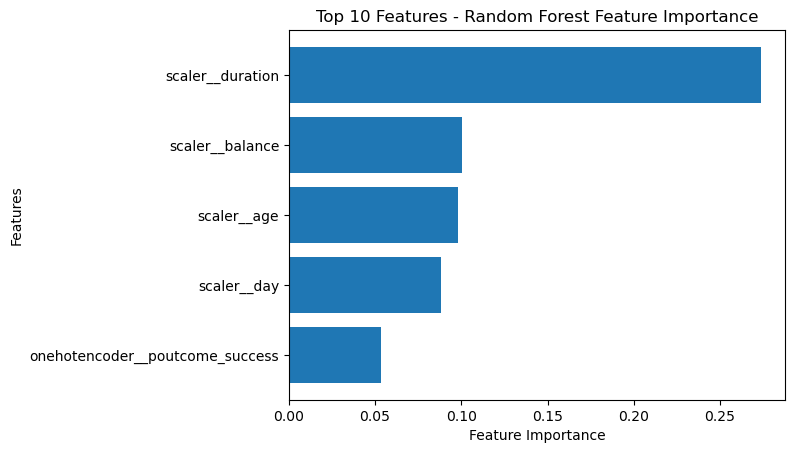

In [51]:
plt.barh(y=top10["Feature"],width=top10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Features - Random Forest Feature Importance")
plt.show()

### 4.9.2 SelectKBest Feature Selection

SelectKBest is a statistical feature selection technique used to select the most relevant features for predicting the target variable.

In this project, SelectKBest evaluates the relationship between each input feature and the binary target variable. A statistical score is calculated for each feature, and the features with the highest scores are selected.

The `f_classif` scoring function is used because this is a classification problem.

SelectKBest will be used to identify the top features from the 42 features obtained after One-Hot Encoding and Feature Scaling.


In [52]:
from sklearn.feature_selection import SelectKBest, f_classif

In [53]:
selector=SelectKBest(score_func=f_classif,k=10)

In [54]:
selector.fit(X_train_encoded, y_train_encoded)

,score_func,<function f_c...001FA9775BB00>
,k,10


In [57]:
X_train_selected = selector.transform(X_train_encoded)
X_train_selected

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 146194 stored elements and shape (36168, 10)>

In [58]:
X_test_selected = selector.transform(X_test_encoded)
X_test_selected

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36408 stored elements and shape (9043, 10)>

In [59]:
selected_features = feature_names[selector.get_support()]
selected_features

array(['onehotencoder__housing_yes', 'onehotencoder__contact_unknown',
       'onehotencoder__month_mar', 'onehotencoder__month_may',
       'onehotencoder__month_oct', 'onehotencoder__month_sep',
       'onehotencoder__poutcome_success',
       'onehotencoder__poutcome_unknown', 'scaler__duration',
       'scaler__pdays'], dtype=object)

### 4.9.3 SelectKBest – Selected Features

SelectKBest with the `f_classif` scoring function was used to select the top 10 features from the 42 transformed features.

The selected features are:

- `housing_yes`
- `contact_unknown`
- `month_mar`
- `month_may`
- `month_oct`
- `month_sep`
- `poutcome_success`
- `poutcome_unknown`
- `duration`
- `pdays`

These features showed the strongest statistical association with the target variable according to the ANOVA F-test.

The selected features will be considered during the subsequent machine learning model development and evaluation.

## 5. Machine Learning Model Building

After preprocessing and feature selection, the prepared dataset is ready for machine learning.

Since the target variable represents whether a customer subscribed to a term deposit, this is a binary classification problem.

Multiple classification algorithms will be trained and evaluated to compare their predictive performance.

The following machine learning algorithms will be considered:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Gradient Boosting

The models will be trained using the prepared training data and evaluated on the unseen testing data.

In [60]:
from sklearn.linear_model import LogisticRegression

In [62]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_selected, y_train_encoded)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [63]:
y_pred_logistic = logistic_model.predict(X_test_selected)

In [64]:
from sklearn.metrics import accuracy_score

In [65]:
accuracy_logistic = accuracy_score(y_test_encoded, y_pred_logistic)
accuracy_logistic

0.901249585314608

In [66]:
from sklearn.metrics import classification_report

In [67]:
print(classification_report(y_test_encoded, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.66      0.33      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.65      0.69      9043
weighted avg       0.89      0.90      0.89      9043



In [68]:
from sklearn.metrics import confusion_matrix

In [69]:
cm_logistic = confusion_matrix(y_test_encoded, y_pred_logistic)
cm_logistic

array([[7803,  182],
       [ 711,  347]])

### 5.7.1 Confusion Matrix – Interpretation

The confusion matrix shows the number of correct and incorrect predictions made by the Logistic Regression model.

The model correctly classified 7,803 customers who did not subscribe and 347 customers who subscribed.

There were 182 false positives, where customers were predicted to subscribe but did not, and 711 false negatives, where customers actually subscribed but were predicted not to subscribe.

The relatively high number of false negatives indicates that the model misses a considerable number of potential customers who would subscribe to a term deposit.

In [71]:
y_prob_logistic = logistic_model.predict_proba(X_test_selected)[:, 1]
from sklearn.metrics import roc_auc_score
roc_auc_logistic = roc_auc_score(y_test_encoded, y_prob_logistic)
roc_auc_logistic

0.8965708387536651

### 5.7.2 Logistic Regression – ROC-AUC Interpretation

The Logistic Regression model achieved a ROC-AUC score of approximately 0.897.

This indicates that the model has a strong ability to distinguish between customers who subscribed to a term deposit and those who did not.

However, the ROC-AUC score should be interpreted together with precision, recall, F1-score, and the confusion matrix. In particular, the recall for the `yes` class is relatively low, indicating that the model misses a considerable number of actual subscribers.

In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree.fit(X_train_selected, y_train_encoded)

# Make predictions on test data
y_pred_tree = decision_tree.predict(X_test_selected)

# Get prediction probabilities for ROC-AUC
y_prob_tree = decision_tree.predict_proba(X_test_selected)[:, 1]

# Calculate evaluation metrics
accuracy_tree = accuracy_score(y_test_encoded, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test_encoded, y_prob_tree)

print("Decision Tree Accuracy:", accuracy_tree)
print("Decision Tree ROC-AUC:", roc_auc_tree)

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_tree))

Decision Tree Accuracy: 0.8852150834899922
Decision Tree ROC-AUC: 0.6974999792853567

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      7985
           1       0.51      0.38      0.44      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.67      0.69      9043
weighted avg       0.87      0.89      0.88      9043


Confusion Matrix:
[[7604  381]
 [ 657  401]]


### 5.8 Decision Tree – Evaluation

The Decision Tree model achieved an accuracy of approximately 88.52% and a ROC-AUC score of approximately 0.697.

For the positive `yes` class, the model achieved a precision of 51%, recall of 38%, and F1-score of 44%.

Compared with Logistic Regression, the Decision Tree achieved slightly higher recall for the positive class, identifying more actual subscribers. However, it produced more false positives and achieved lower overall accuracy and ROC-AUC.

The performance of the Decision Tree will be compared with the remaining classification models before selecting the most suitable model.

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Create the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train_selected, y_train_encoded)

# Make predictions on test data
y_pred_rf = random_forest.predict(X_test_selected)

# Get prediction probabilities for ROC-AUC
y_prob_rf = random_forest.predict_proba(X_test_selected)[:, 1]

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test_encoded, y_prob_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_rf))

Random Forest Accuracy: 0.8895278115669578
Random Forest ROC-AUC: 0.8498015537166214

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7985
           1       0.54      0.39      0.45      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.67      0.69      9043
weighted avg       0.88      0.89      0.88      9043


Confusion Matrix:
[[7636  349]
 [ 650  408]]


### 5.9 Random Forest – Evaluation

The Random Forest model achieved an accuracy of approximately 88.95% and a ROC-AUC score of approximately 0.850.

For the positive `yes` class, the model achieved a precision of 54%, recall of 39%, and F1-score of 45%.

Compared with the Decision Tree, Random Forest achieved better ROC-AUC and slightly better positive-class performance. It also produced fewer false negatives, correctly identifying more potential subscribers.

However, Logistic Regression still achieved higher overall accuracy and ROC-AUC on the selected feature set.

The remaining classification models will be evaluated before selecting the final model.

In [74]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Create the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_selected, y_train_encoded)

# Make predictions on test data
y_pred_knn = knn.predict(X_test_selected)

# Get prediction probabilities for ROC-AUC
y_prob_knn = knn.predict_proba(X_test_selected)[:, 1]

# Calculate evaluation metrics
accuracy_knn = accuracy_score(y_test_encoded, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test_encoded, y_prob_knn)

print("KNN Accuracy:", accuracy_knn)
print("KNN ROC-AUC:", roc_auc_knn)

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_knn))

KNN Accuracy: 0.8942828707287405
KNN ROC-AUC: 0.8315852739008515

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7985
           1       0.57      0.41      0.48      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.89      9043


Confusion Matrix:
[[7653  332]
 [ 624  434]]


### 5.10 K-Nearest Neighbors – Evaluation

The K-Nearest Neighbors model achieved an accuracy of approximately 89.43% and a ROC-AUC score of approximately 0.832.

For the positive `yes` class, the model achieved a precision of 57%, recall of 41%, and F1-score of 48%.

Among the models evaluated so far, KNN achieved the highest recall and F1-score for the positive class. It also produced the lowest number of false negatives among the four models.

However, Logistic Regression still achieved higher overall accuracy and ROC-AUC. The remaining models will be evaluated before selecting the final model.

In [75]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Create the SVM model
svm_model = SVC(
    probability=True,
    random_state=42
)

# Train the model
svm_model.fit(X_train_selected, y_train_encoded)

# Make predictions on test data
y_pred_svm = svm_model.predict(X_test_selected)

# Get prediction probabilities for ROC-AUC
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test_encoded, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test_encoded, y_prob_svm)

print("SVM Accuracy:", accuracy_svm)
print("SVM ROC-AUC:", roc_auc_svm)

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_svm))

SVM Accuracy: 0.9024659957978547
SVM ROC-AUC: 0.8110514989707781

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.65      0.35      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:
[[7788  197]
 [ 685  373]]


### 5.11 Support Vector Machine – Evaluation

The Support Vector Machine (SVM) model achieved an accuracy of approximately 90.25% and a ROC-AUC score of approximately 0.811.

For the positive `yes` class, the model achieved a precision of 65%, recall of 35%, and F1-score of 46%.

The SVM model achieved slightly higher accuracy than Logistic Regression. However, its ROC-AUC score was lower than Logistic Regression. The model also identified fewer actual subscribers than KNN and Random Forest based on the positive-class recall.

Therefore, SVM does not clearly outperform the previously evaluated models. The remaining models will be evaluated before selecting the most suitable model.

In [76]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Create the Gradient Boosting model
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
gradient_boosting.fit(X_train_selected, y_train_encoded)

# Make predictions on test data
y_pred_gb = gradient_boosting.predict(X_test_selected)

# Get prediction probabilities for ROC-AUC
y_prob_gb = gradient_boosting.predict_proba(X_test_selected)[:, 1]

# Calculate evaluation metrics
accuracy_gb = accuracy_score(y_test_encoded, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test_encoded, y_prob_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("Gradient Boosting ROC-AUC:", roc_auc_gb)

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_gb))

Gradient Boosting Accuracy: 0.9025765785690589
Gradient Boosting ROC-AUC: 0.9048487653480711

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.38      0.48      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.68      0.71      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:
[[7759  226]
 [ 655  403]]


### 5.12 Gradient Boosting – Evaluation

The Gradient Boosting model achieved an accuracy of approximately 90.26% and a ROC-AUC score of approximately 0.905.

For the positive `yes` class, the model achieved a precision of 64%, recall of 38%, and F1-score of 48%.

Gradient Boosting achieved the highest ROC-AUC score among the models evaluated so far, indicating strong ability to distinguish between customers who subscribed and those who did not.

Its accuracy was also the highest, although it was very close to the accuracy of the SVM model.

KNN achieved a higher recall for the positive class, while Gradient Boosting provided stronger overall discrimination according to ROC-AUC.

The performance of all six models will now be compared before selecting a model for further tuning.

In [77]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_knn,
        accuracy_svm,
        accuracy_gb
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_knn,
        roc_auc_svm,
        roc_auc_gb
    ],
    "Precision_yes": [
        0.66,
        0.51,
        0.54,
        0.57,
        0.65,
        0.64
    ],
    "Recall_yes": [
        0.33,
        0.38,
        0.39,
        0.41,
        0.35,
        0.38
    ],
    "F1_yes": [
        0.44,
        0.44,
        0.45,
        0.48,
        0.46,
        0.48
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC,Precision_yes,Recall_yes,F1_yes
0,Logistic Regression,0.901250,0.896571,0.66,0.33,0.44
1,Decision Tree,0.885215,0.697500,0.51,0.38,0.44
2,Random Forest,0.889528,0.849802,0.54,0.39,0.45
3,KNN,0.894283,0.831585,0.57,0.41,0.48
4,SVM,0.902466,0.811051,0.65,0.35,0.46
5,Gradient Boosting,0.902577,0.904849,0.64,0.38,0.48


### 5.13 Model Comparison – Interpretation

The six classification models were compared using accuracy, ROC-AUC, precision, recall, and F1-score for the positive `yes` class.

Gradient Boosting achieved the highest accuracy of approximately 90.26% and the highest ROC-AUC of approximately 90.48%. It also achieved an F1-score of 48% for the positive class.

K-Nearest Neighbors achieved the highest recall for the positive class at 41%, indicating that it identified more actual subscribers than the other models at the current classification threshold.

Logistic Regression achieved a strong ROC-AUC of approximately 89.66%, while Decision Tree produced the lowest ROC-AUC among the six models.

Since the target variable is imbalanced, accuracy alone is not sufficient for selecting the best model. ROC-AUC and positive-class precision, recall, and F1-score are also considered.

Based on the current results, Gradient Boosting is selected as the leading candidate for further hyperparameter tuning. The final model will be confirmed after tuning and additional evaluation.

### 6.1 Confusion Matrix – Gradient Boosting

A confusion matrix is used to evaluate the classification performance of the Gradient Boosting model.

It shows the number of:
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

This provides a detailed view of the correct and incorrect predictions made by the model.

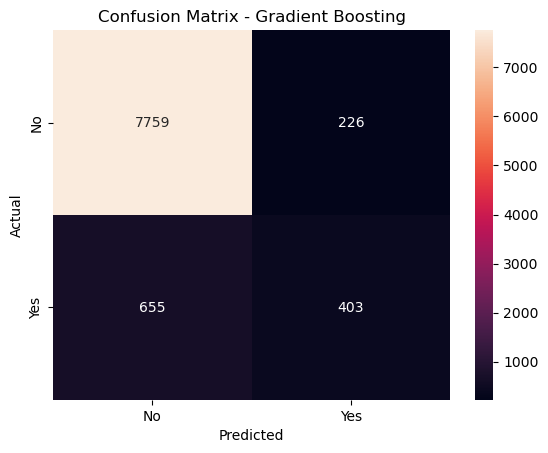

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gb = confusion_matrix(y_test_encoded, y_pred_gb)

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

### 6.2 ROC Curve – Gradient Boosting

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of the Gradient Boosting model to distinguish between the two target classes.

The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the overall discriminatory ability of the model. A higher ROC-AUC indicates better separation between the positive and negative classes.

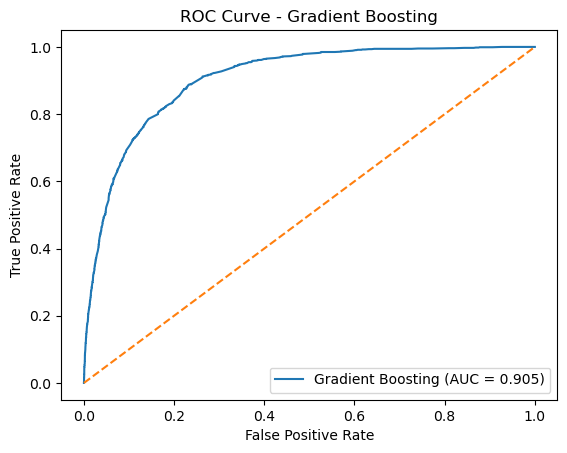

In [79]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob_gb)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test_encoded, y_prob_gb)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc:.3f})")

# Plot random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

### 6.3 Precision, Recall and F1-Score – Gradient Boosting

Precision, recall, and F1-score are used to evaluate the performance of the Gradient Boosting model for the positive `yes` class.

- **Precision** measures how many customers predicted as subscribers actually subscribed.
- **Recall** measures how many of the actual subscribers were correctly identified.
- **F1-score** provides a balance between precision and recall.

These metrics are particularly important in this project because the target variable is imbalanced.

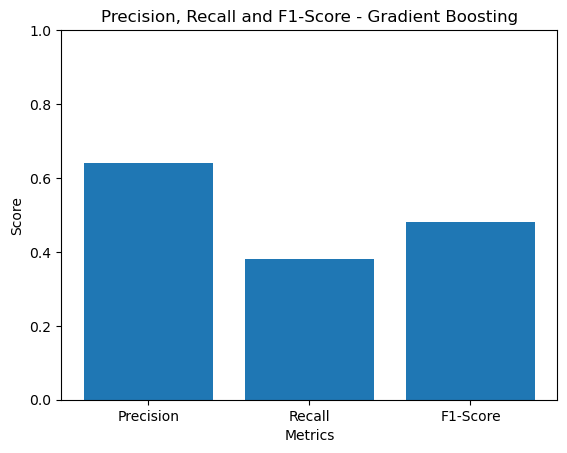

In [80]:
metrics = ["Precision", "Recall", "F1-Score"]
values = [0.64, 0.38, 0.48]

plt.bar(metrics, values)

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score - Gradient Boosting")
plt.ylim(0, 1)

plt.show()

## 7.1 Hyperparameter Tuning Using GridSearchCV

Hyperparameter tuning is used to identify the combination of model settings
that provides the best predictive performance.

GridSearchCV systematically evaluates different combinations of
hyperparameters using cross-validation.

In this project, Gradient Boosting is selected for tuning because it achieved
the highest ROC-AUC among the initial models.

ROC-AUC is used as the scoring metric because the target variable is imbalanced.

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Create the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Define hyperparameter values to test
param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

# Perform hyperparameter tuning
grid_search.fit(X_train_selected, y_train_encoded)

# Display the best parameters and score
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}

Best Cross-Validation ROC-AUC:
0.9036568119788954


### 7.2 Hyperparameter Tuning – Results

GridSearchCV identified the following hyperparameters as the best combination
for the Gradient Boosting model:

- `n_estimators = 150`
- `learning_rate = 0.1`
- `max_depth = 3`

The best cross-validation ROC-AUC obtained during hyperparameter tuning was
approximately 0.904.

The tuned model will now be evaluated on the unseen test dataset to determine
whether the optimized hyperparameters improve the model's generalization
performance.

### 7.3 Tuned Gradient Boosting – Test Evaluation

The best hyperparameters identified by GridSearchCV are used to create a tuned
Gradient Boosting model.

The tuned model is evaluated on the unseen test dataset using accuracy,
precision, recall, F1-score, ROC-AUC, and a confusion matrix.

This evaluation determines whether hyperparameter tuning improves the model's
performance on unseen data.

In [82]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Create the tuned Gradient Boosting model
tuned_gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the tuned model
tuned_gb.fit(X_train_selected, y_train_encoded)

# Make predictions on the unseen test data
y_pred_tuned_gb = tuned_gb.predict(X_test_selected)

# Get prediction probabilities for ROC-AUC
y_prob_tuned_gb = tuned_gb.predict_proba(X_test_selected)[:, 1]

# Calculate evaluation metrics
accuracy_tuned_gb = accuracy_score(
    y_test_encoded,
    y_pred_tuned_gb
)

roc_auc_tuned_gb = roc_auc_score(
    y_test_encoded,
    y_prob_tuned_gb
)

print("Tuned Gradient Boosting Accuracy:", accuracy_tuned_gb)
print("Tuned Gradient Boosting ROC-AUC:", roc_auc_tuned_gb)

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_tuned_gb
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_encoded,
    y_pred_tuned_gb
))

Tuned Gradient Boosting Accuracy: 0.9019130819418335
Tuned Gradient Boosting ROC-AUC: 0.9059185879005177

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.38      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.68      0.71      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:
[[7755  230]
 [ 657  401]]


### 7.4 Tuned Gradient Boosting – Interpretation

The tuned Gradient Boosting model achieved an accuracy of approximately 90.19%
and a ROC-AUC score of approximately 90.59% on the unseen test dataset.

Compared with the original Gradient Boosting model, hyperparameter tuning produced
a small improvement in ROC-AUC, from approximately 90.48% to 90.59%.

However, the accuracy decreased slightly from 90.26% to 90.19%, while the
positive-class F1-score changed from 48% to 47%.

Therefore, hyperparameter tuning did not produce a major improvement in overall
classification performance. However, the tuned model achieved the highest
ROC-AUC observed in the current experiments and is retained as the final model
candidate.

The confusion matrix shows 7,755 true negatives, 230 false positives,
657 false negatives, and 401 true positives.

The relatively high number of false negatives indicates that the model still
misses a considerable number of actual subscribers. This is an important
limitation that can be addressed through further techniques such as threshold
optimization or class-imbalance handling.

## 8. Pipeline

A machine learning pipeline combines multiple data preprocessing and modeling
steps into a single workflow.

In this project, the pipeline will automatically perform:

1. One-Hot Encoding of categorical features
2. Standard Scaling of numerical features
3. Feature Selection using SelectKBest
4. Gradient Boosting classification

Using a pipeline ensures that the same preprocessing steps are consistently
applied to training data, testing data, and future unseen data.

It also helps reduce the risk of data leakage during model training and
cross-validation.

### 8.1 Creating the Machine Learning Pipeline

The preprocessing, feature selection, and Gradient Boosting model are combined
into a single machine learning pipeline.

The pipeline will be trained using the original training features rather than
the already transformed data. This allows each preprocessing and feature
selection step to be handled automatically as part of the complete workflow.

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier

# Preprocessing for categorical features
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

# Combine categorical encoding and numerical scaling
pipeline_preprocessor = ColumnTransformer([
    ("categorical", encoder, categorical_cols),
    ("numerical", StandardScaler(), numerical_cols)
])

# Create the complete machine learning pipeline
final_pipeline = Pipeline([
    ("preprocessor", pipeline_preprocessor),
    ("feature_selection", SelectKBest(
        score_func=f_classif,
        k=10
    )),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Train the complete pipeline
final_pipeline.fit(X_train, y_train_encoded)

print("Pipeline training completed successfully.")

Pipeline training completed successfully.


### 8.2 Pipeline Evaluation

The complete machine learning pipeline is evaluated using the unseen test
dataset.

The pipeline automatically performs preprocessing, feature selection, and
prediction before calculating the evaluation metrics.

Accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix are
used to evaluate the final pipeline.

In [84]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Make predictions using the complete pipeline
y_pred_pipeline = final_pipeline.predict(X_test)

# Get prediction probabilities for ROC-AUC
y_prob_pipeline = final_pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_pipeline = accuracy_score(
    y_test_encoded,
    y_pred_pipeline
)

roc_auc_pipeline = roc_auc_score(
    y_test_encoded,
    y_prob_pipeline
)

print("Pipeline Accuracy:", accuracy_pipeline)
print("Pipeline ROC-AUC:", roc_auc_pipeline)

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_pipeline
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_encoded,
    y_pred_pipeline
))

Pipeline Accuracy: 0.9019130819418335
Pipeline ROC-AUC: 0.9059185879005177

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.38      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.68      0.71      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:
[[7755  230]
 [ 657  401]]


### 8.3 Final Pipeline – Evaluation Results

The complete machine learning pipeline achieved an accuracy of approximately
90.19% and a ROC-AUC score of approximately 90.59% on the unseen test dataset.

For the positive `yes` class, the pipeline achieved a precision of 64%,
recall of 38%, and F1-score of 47%.

The confusion matrix contains 7,755 true negatives, 230 false positives,
657 false negatives, and 401 true positives.

The pipeline produced the same results as the tuned Gradient Boosting model
because it uses the same preprocessing, feature selection, and optimized
Gradient Boosting hyperparameters.

The final pipeline is therefore selected as the model candidate for deployment
and further testing with unseen customer data.

## 9. Saving the Final Model

The final machine learning pipeline is saved so that it can be reused without
training the model again.

The complete pipeline contains the preprocessing steps, feature selection,
and tuned Gradient Boosting model.

Saving the complete pipeline also ensures that the same transformations are
automatically applied when the model is used with new unseen data.

### 9.1 Saving the Final Pipeline

The trained final pipeline is serialized and stored as a `.pkl` file using
Joblib.

The saved file contains the complete trained machine learning workflow.

In [85]:
import joblib

# Save the complete trained pipeline
model_path = "bank_marketing_final_pipeline.pkl"

joblib.dump(final_pipeline, model_path)

print("Final pipeline saved successfully.")
print("File:", model_path)

Final pipeline saved successfully.
File: bank_marketing_final_pipeline.pkl


### 9.2 Loading the Saved Pipeline

The saved machine learning pipeline is loaded back into the Python environment
using Joblib.

This verifies that the trained model can be restored from the saved file and
used for prediction without retraining the model.

In [86]:
import joblib

# Load the saved pipeline
loaded_pipeline = joblib.load("bank_marketing_final_pipeline.pkl")

print("Saved pipeline loaded successfully.")
print(type(loaded_pipeline))

Saved pipeline loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [ ]:
import sys
import sklearn
import scipy
import numpy
import pandas
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Joblib:", joblib.__version__)